Configuración del entorno


---
Montamos Google Drive y configuramos las rutas. El dataset vive en
/content/DATA_R1_R2_LIMPIO_COPIA_ENTRENAMIENTO.csv

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = '/content/DATA_R1_R2_LIMPIO_COPIA_ENTRENAMIENTO.csv'

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
print('Entorno listo')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Entorno listo


Carga del dataset

In [4]:
df = pd.read_csv(DATA_PATH, sep=';')
print(f'Registros: {len(df):,}   |   Columnas: {df.shape[1]}')
df.head()

Registros: 1,813   |   Columnas: 31


,id,acido_urico,c_total,creatinina,celulas_medias,glucosa,granulocitos,hdl,hematocrito,hemoglobina,...,ap_hipertension,af_diabetes,af_hipertension,ta_sistolica,ta_diastolica,peso,talla,imc,TFG,Estadio_TFG
0,1,NaN,NaN,0.5,1.0,NaN,58.0,NaN,45.0,15.0,...,0.0,0.0,0.0,111.0,73.0,88.7,154.0,37.40,132.64,1.0
1,2,NaN,NaN,NaN,3.0,NaN,63.0,NaN,45.0,15.0,...,0.0,0.0,0.0,110.0,70.0,56.0,158.0,22.43,NaN,NaN
2,3,NaN,227.0,0.9,NaN,79.0,NaN,45.4,NaN,NaN,...,0.0,0.0,0.0,110.0,70.0,65.0,160.0,25.39,107.97,1.0
3,4,NaN,186.0,0.6,3.0,88.0,67.0,37.2,45.0,15.0,...,0.0,NaN,NaN,NaN,NaN,63.0,160.0,24.61,127.58,1.0
4,5,NaN,122.0,1.0,1.0,89.0,65.0,24.4,44.0,14.6,...,0.0,0.0,0.0,110.0,70.0,62.7,162.0,23.89,103.41,1.0


In [5]:
import pandas as pd
import numpy as np

# Define DATA_PATH explicitly within this cell to ensure it's always available.
DATA_PATH = '/content/DATA_R1_R2_LIMPIO_COPIA_ENTRENAMIENTO.csv'

#  1. DUPLICADOS
df = pd.read_csv(DATA_PATH, sep=';') # Re-initialize df to ensure it's defined
df = df.drop_duplicates()
print(f"Filas tras eliminar duplicados: {len(df)}")

#  2. ERRORES OBVIOS POR RANGO CLÍNICO → convertir a NaN
rangos = {
    'acido_urico':    (1.5, 20),
    'c_total':        (50, 500),
    'creatinina':     (0.3, 20),
    'glucosa':        (30, 600),
    'hdl':            (10, 150),
    'hematocrito':    (10, 65),
    'hemoglobina':    (3, 25),
    'ldl':            (10, 400),
    'trigliceridos':  (20, 1000),
    'edad':           (0, 110),
    'ta_sistolica':   (60, 250),
    'ta_diastolica':  (30, 150),
    'peso':           (20, 200),
    'talla':          (100, 220),
    'imc':            (10, 70),
    'TFG':            (1, 200),
}

print("\n=== VALORES CORREGIDOS A NaN ===")
for col, (minv, maxv) in rangos.items():
    if col not in df.columns:
        continue
    mask = (df[col] < minv) | (df[col] > maxv)
    n = mask.sum()
    if n > 0:
        print(f"  {col}: {n} valores fuera de [{minv}, {maxv}] → NaN")
        df.loc[mask, col] = np.nan

#  3. COLUMNAS CON > 50% NULOS → eliminar
cols_altas = [c for c in df.columns if df[c].isnull().mean() > 0.5]
print(f"\n=== COLUMNAS ELIMINADAS (>50% nulos) ===")
for c in cols_altas:
    print(f"  {c}: {df[c].isnull().mean()*100:.1f}% nulos")
df = df.drop(columns=cols_altas)

#  4. RESUMEN FINAL
print(f"\n=== RESUMEN FINAL ===")
print(f"Filas: {len(df)}  |  Columnas: {len(df.columns)}")
print("\n% Nulos restantes:")
pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(pct[pct > 0].round(1).to_string())

#  5. GUARDAR
df.to_csv("datos_limpios.csv", index=False, sep=';')
print("\n✔ Guardado: datos_limpios.csv")

Filas tras eliminar duplicados: 1813

=== VALORES CORREGIDOS A NaN ===
  acido_urico: 1 valores fuera de [1.5, 20] → NaN
  c_total: 4 valores fuera de [50, 500] → NaN
  creatinina: 19 valores fuera de [0.3, 20] → NaN
  glucosa: 4 valores fuera de [30, 600] → NaN
  hematocrito: 3 valores fuera de [10, 65] → NaN
  hemoglobina: 12 valores fuera de [3, 25] → NaN
  ldl: 1 valores fuera de [10, 400] → NaN
  trigliceridos: 1 valores fuera de [20, 1000] → NaN
  ta_sistolica: 14 valores fuera de [60, 250] → NaN
  ta_diastolica: 12 valores fuera de [30, 150] → NaN
  peso: 73 valores fuera de [20, 200] → NaN
  talla: 58 valores fuera de [100, 220] → NaN
  imc: 46 valores fuera de [10, 70] → NaN
  TFG: 16 valores fuera de [1, 200] → NaN

=== COLUMNAS ELIMINADAS (>50% nulos) ===
  acido_urico: 88.1% nulos

=== RESUMEN FINAL ===
Filas: 1813  |  Columnas: 30

% Nulos restantes:
ldl                           38.7
hdl                           37.2
Estadio_TFG                   26.7
creatinina         

# EDA

### 1. Tipos de datos

In [6]:
print('=== Tipos de datos ===')
print(df.dtypes)
print()
print('=== Valores nulos por columna ===')
print(df.isnull().sum())

=== Tipos de datos ===
id                              int64
c_total                       float64
creatinina                    float64
celulas_medias                float64
glucosa                       float64
granulocitos                  float64
hdl                           float64
hematocrito                   float64
hemoglobina                   float64
ldl                           float64
leucocitos                    float64
linfocitos                    float64
plaquetas                     float64
trigliceridos                 float64
edad                            int64
sexo                            int64
zona                            int64
cigarrillo_cantidad_diaria    float64
alcohol_anos_uso              float64
ap_diabetes                   float64
ap_hipertension               float64
af_diabetes                   float64
af_hipertension               float64
ta_sistolica                  float64
ta_diastolica                 float64
peso                       

### 2.  Descripción de variables


| Variable | Descripción |
|---|---|
| id | Identificador único del paciente — se descarta antes de entrenar |
| c_total | Colesterol total (mg/dL) |
| creatinina | Nivel de creatinina en sangre (mg/dL) — indicador de función renal |
| celulas_medias | Células de tamaño medio en hemograma |
| glucosa | Nivel de glucosa en sangre (mg/dL) |
| granulocitos | Conteo de granulocitos (% o valor absoluto) |
| hdl | Colesterol HDL — lipoproteína de alta densidad (mg/dL) |
| hematocrito | Porcentaje de glóbulos rojos en sangre (%) |
| hemoglobina | Concentración de hemoglobina en sangre (g/dL) |
| ldl | Colesterol LDL — lipoproteína de baja densidad (mg/dL) |
| leucocitos | Conteo total de glóbulos blancos (10³/µL) |
| linfocitos | Conteo de linfocitos (% o valor absoluto) |
| plaquetas | Conteo de plaquetas (10³/µL) |
| trigliceridos | Nivel de triglicéridos en sangre (mg/dL) |
| edad | Edad del paciente en años |
| sexo | Sexo biológico · 0 = femenino · 1 = masculino |
| zona | Zona geográfica o de residencia 0 = rural 1 = urbana |
| cigarrillo_cantidad_diaria | Número de cigarrillos consumidos por día |
| alcohol_anos_uso | Años de consumo de alcohol |
| ap_diabetes | Antecedente personal de diabetes · 0 = no · 1 = sí |
| ap_hipertension | Antecedente personal de hipertensión · 0 = no · 1 = sí |
| af_diabetes | Antecedente familiar de diabetes · 0 = no · 1 = sí |
| af_hipertension | Antecedente familiar de hipertensión · 0 = no · 1 = sí |
| ta_sistolica | Tensión arterial sistólica (mmHg) |
| ta_diastolica | Tensión arterial diastólica (mmHg) |
| peso | Peso corporal (kg) |
| talla | Talla o estatura (cm) |
| imc | Índice de Masa Corporal = peso / talla² (kg/m²) |
| TFG | Tasa de Filtración Glomerular — función renal (mL/min/1.73m²) |


### 3. Analisis univariado

**3.1. Medidas de tendencia central**

In [7]:
# Calculate for numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns
if not numerical_cols.empty:
    print('--- Variables Numéricas ---')
    numerical_stats = pd.DataFrame({
        'mean': df[numerical_cols].mean(),
        'median': df[numerical_cols].median(),
        'mode': df[numerical_cols].mode().iloc[0] # .iloc[0] to handle cases with multiple modes
    })
    display(numerical_stats.round(2))
else:
    print("No se encontraron columnas numéricas.")

print('\n--- Variables Categóricas/Objeto (Moda) ---')
# Calculate mode for object/categorical columns
object_cols = df.select_dtypes(include='object').columns
if not object_cols.empty:
    object_modes = pd.DataFrame({'mode': df[object_cols].mode().iloc[0]})
    display(object_modes)
else:
    print("No se encontraron columnas categóricas/objeto.")

--- Variables Numéricas ---


,mean,median,mode
id,907.00,907.00,1.00
c_total,203.27,196.00,174.00
creatinina,0.73,0.60,0.60
celulas_medias,351.99,3.00,1.00
glucosa,100.06,94.00,98.00
granulocitos,62.69,61.00,63.00
hdl,41.67,40.00,34.80
hematocrito,41.60,41.00,40.00
hemoglobina,13.88,13.60,13.30
ldl,132.62,126.30,122.20



--- Variables Categóricas/Objeto (Moda) ---
No se encontraron columnas categóricas/objeto.


**3.2. Medidas de dispersion**

In [8]:
print('=== Medidas de Dispersión ===\n')

numerical_cols = df.select_dtypes(include=np.number).columns

if not numerical_cols.empty:
    dispersion_stats = pd.DataFrame({
        'std': df[numerical_cols].std(),
        'var': df[numerical_cols].var(),
        'min': df[numerical_cols].min(),
        'max': df[numerical_cols].max(),
        'range': df[numerical_cols].max() - df[numerical_cols].min(),
        'q1': df[numerical_cols].quantile(0.25),
        'q3': df[numerical_cols].quantile(0.75),
        'iqr': df[numerical_cols].quantile(0.75) - df[numerical_cols].quantile(0.25)
    })
    display(dispersion_stats.round(2))
else:
    print("No se encontraron columnas numéricas para calcular las medidas de dispersión.")

=== Medidas de Dispersión ===



,std,var,min,max,range,q1,q3,iqr
id,523.51,2.740652e+05,1.00,1813.00,1812.00,454.00,1360.00,906.00
c_total,63.32,4.009050e+03,64.00,470.00,406.00,162.00,240.00,78.00
creatinina,0.65,4.300000e-01,0.30,16.50,16.20,0.50,0.80,0.30
celulas_medias,10113.22,1.022772e+08,1.00,345000.00,344999.00,2.00,6.00,4.00
glucosa,34.83,1.212800e+03,47.00,492.00,445.00,85.00,104.00,19.00
granulocitos,32.81,1.076780e+03,25.00,725.00,700.00,55.00,67.75,12.75
hdl,13.27,1.762100e+02,12.80,121.00,108.20,33.00,49.70,16.70
hematocrito,5.07,2.572000e+01,12.60,56.00,43.40,39.00,45.00,6.00
hemoglobina,1.47,2.160000e+00,5.00,19.00,14.00,13.00,15.00,2.00
ldl,49.26,2.426870e+03,14.60,375.20,360.60,98.57,162.60,64.03


**3.3. Medidas de forma y distribución**

Asimetría (Skewness): Indica si los datos se inclinan más hacia la derecha o hacia la izquierda.

Curtosis: Mide qué tan "puntiaguda" o plana es la distribución en comparación con una distribución normal.

In [9]:
print('=== Asimetría y Curtosis ===\n')

numerical_cols = df.select_dtypes(include=np.number).columns

if not numerical_cols.empty:
    skew_kurt_stats = pd.DataFrame({
        'skewness': df[numerical_cols].skew(),
        'kurtosis': df[numerical_cols].kurt()
    })
    display(skew_kurt_stats.round(2))
else:
    print("No se encontraron columnas numéricas para calcular asimetría y curtosis.")

=== Asimetría y Curtosis ===



,skewness,kurtosis
id,0.00,-1.20
c_total,0.65,0.66
creatinina,14.15,286.82
celulas_medias,30.48,963.26
glucosa,5.63,44.52
granulocitos,17.90,349.56
hdl,0.95,2.50
hematocrito,-1.27,6.03
hemoglobina,-0.44,1.72
ldl,0.64,0.88


**4.4. Visualización de datos**

**4.4.1. Histograma**

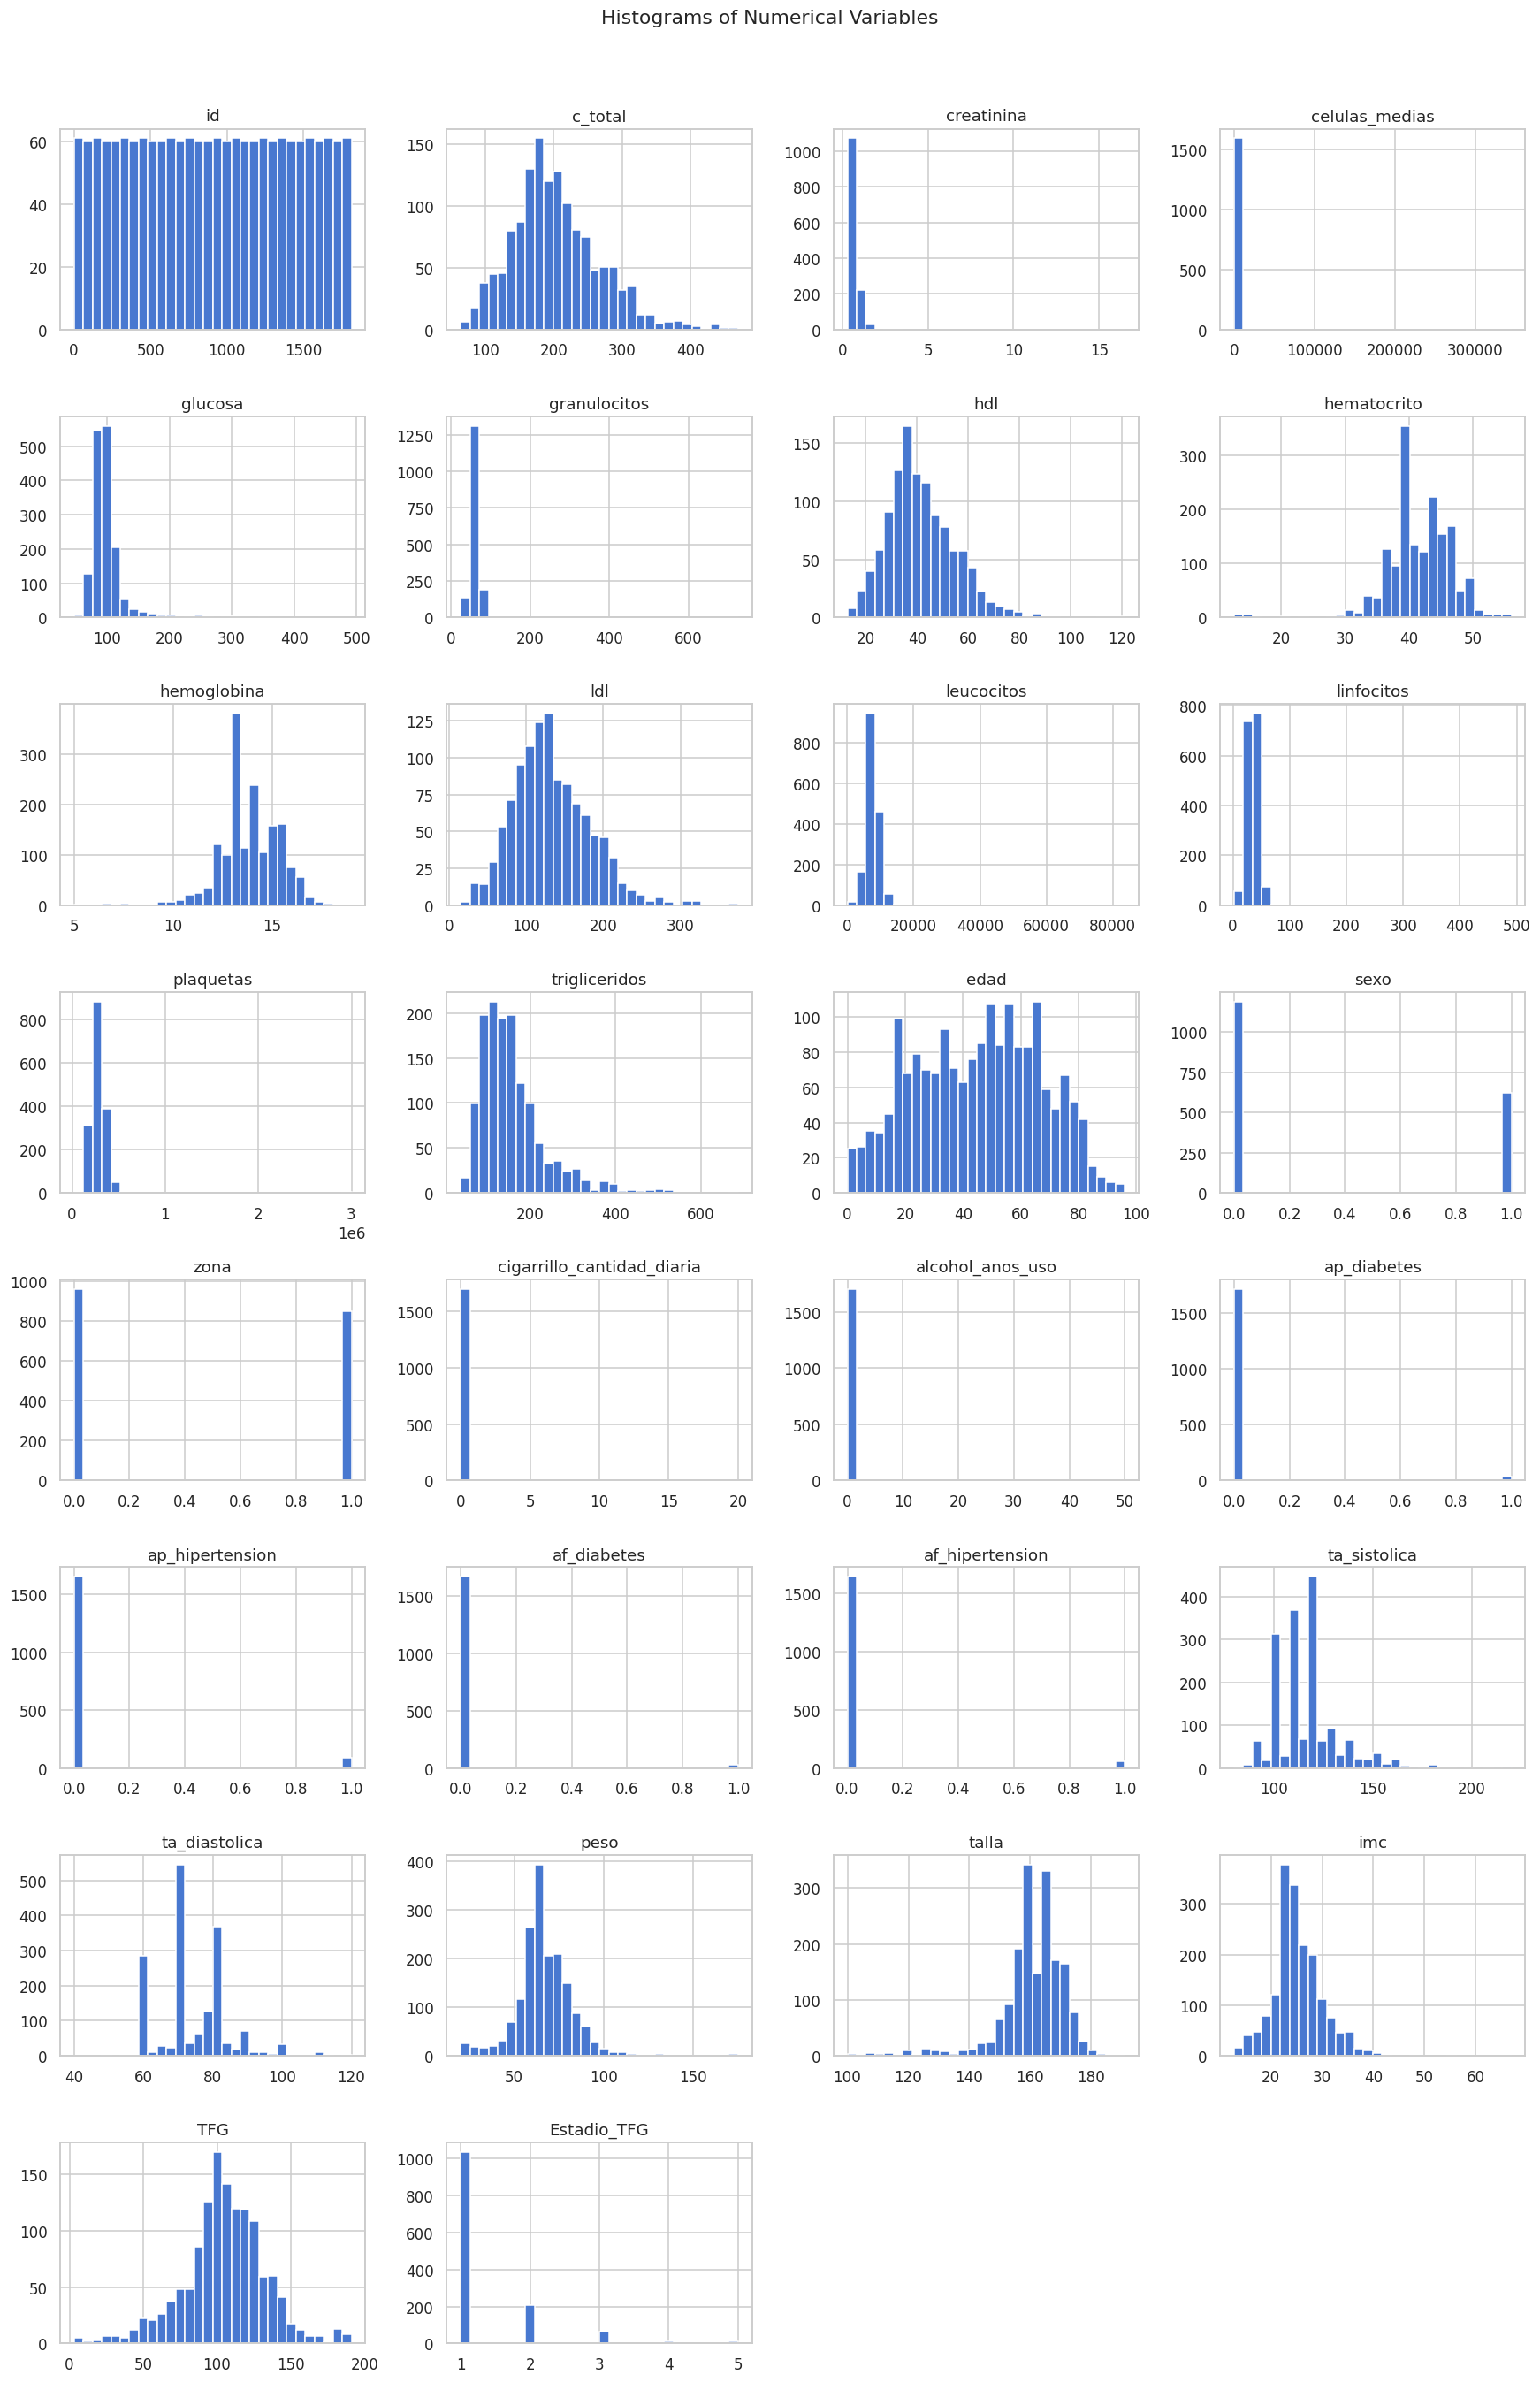

In [10]:
numerical_cols = df.select_dtypes(include=np.number).columns

if not numerical_cols.empty:
    num_plots = len(numerical_cols)
    num_cols = 4  # Number of columns for the subplot grid
    num_rows = (num_plots + num_cols - 1) // num_cols # Calculate rows needed

    df[numerical_cols].hist(bins=30, figsize=(num_cols * 4, num_rows * 3), layout=(num_rows, num_cols))
    plt.suptitle('Histograms of Numerical Variables', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No se encontraron columnas numéricas para graficar histogramas.")

**4.4.2 Boxplots**

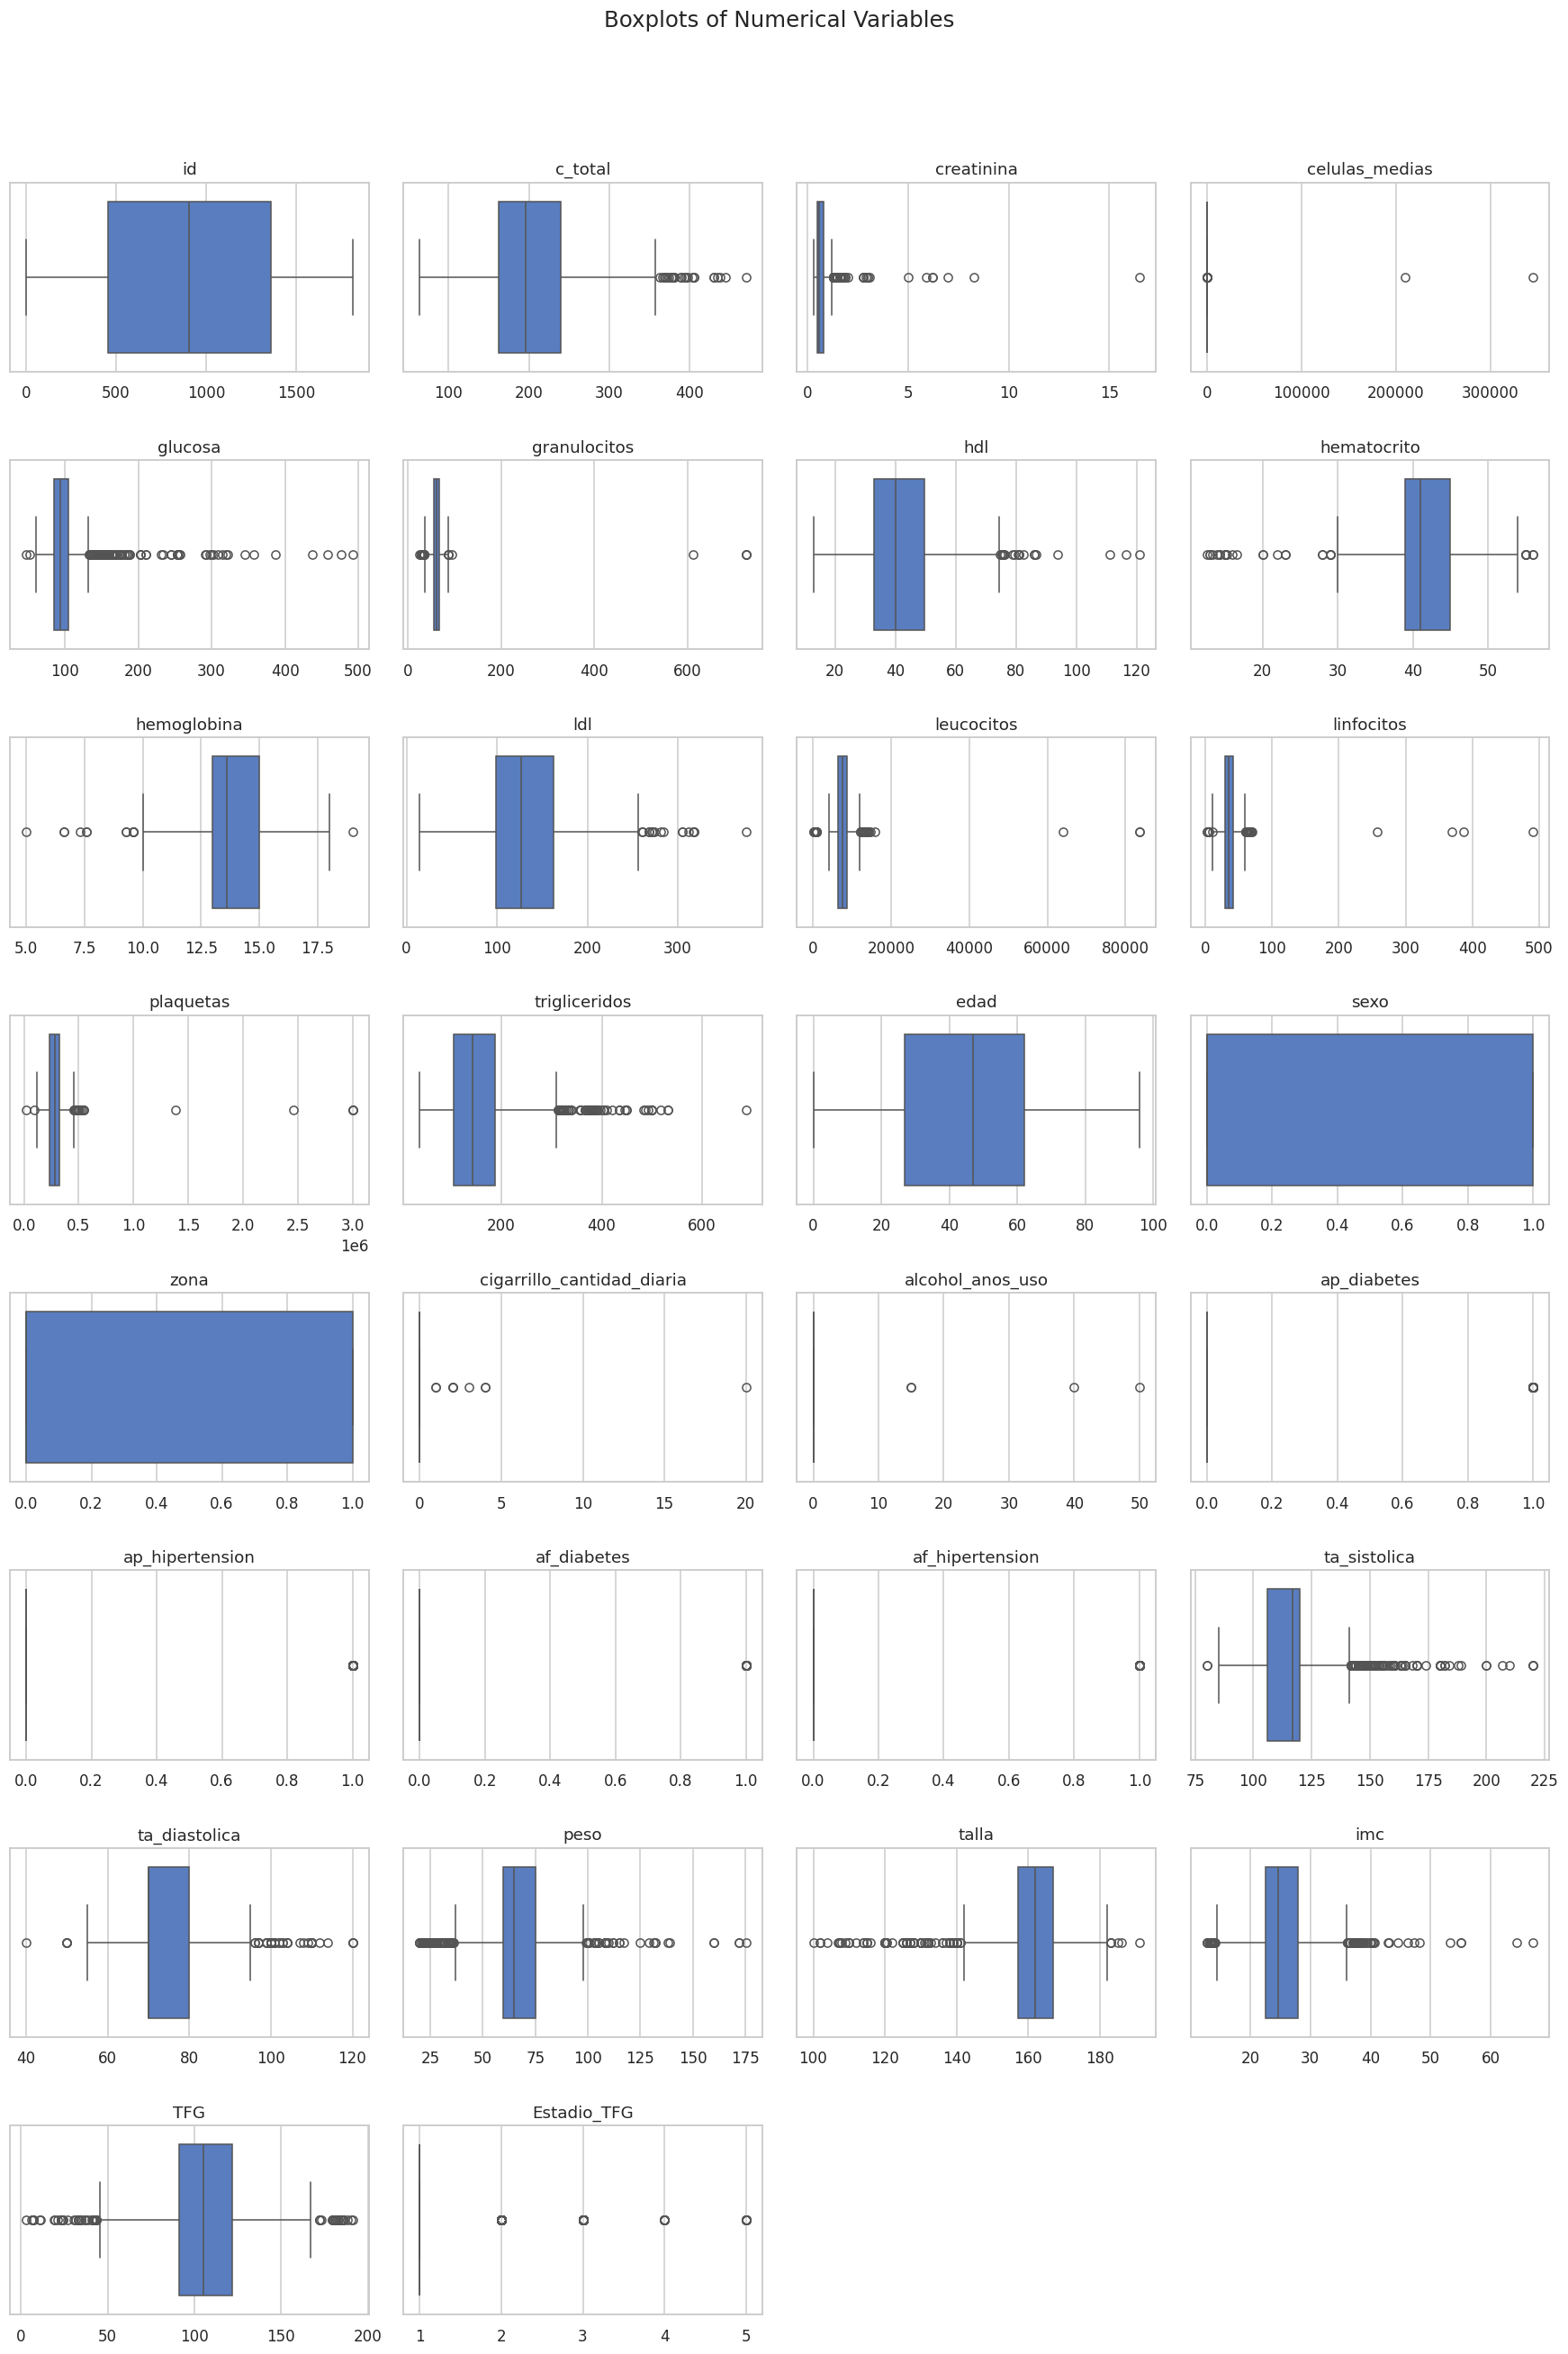

In [11]:
numerical_cols = df.select_dtypes(include=np.number).columns

if not numerical_cols.empty:
    num_plots = len(numerical_cols)
    num_cols = 4 # Number of columns for the subplot grid
    num_rows = (num_plots + num_cols - 1) // num_cols # Calculate rows needed

    plt.figure(figsize=(num_cols * 4, num_rows * 3))
    plt.suptitle('Boxplots of Numerical Variables', y=1.02, fontsize=16)

    for i, col in enumerate(numerical_cols):
        plt.subplot(num_rows, num_cols, i + 1)
        sns.boxplot(x=df[col])
        plt.title(col)
        plt.xlabel('')
        plt.ylabel('')
    plt.tight_layout(rect=[0, 0.03, 1, 0.98])
    plt.show()
else:
    print("No numerical columns found to plot boxplots.")

**4.4.3. Diagrama de barras para variables categoricas**

/tmp/ipykernel_1869/3645308305.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='viridis')
/tmp/ipykernel_1869/3645308305.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='viridis')
/tmp/ipykernel_1869/3645308305.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='viridis')
/tmp/ipykernel_1869/3645308305.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` 

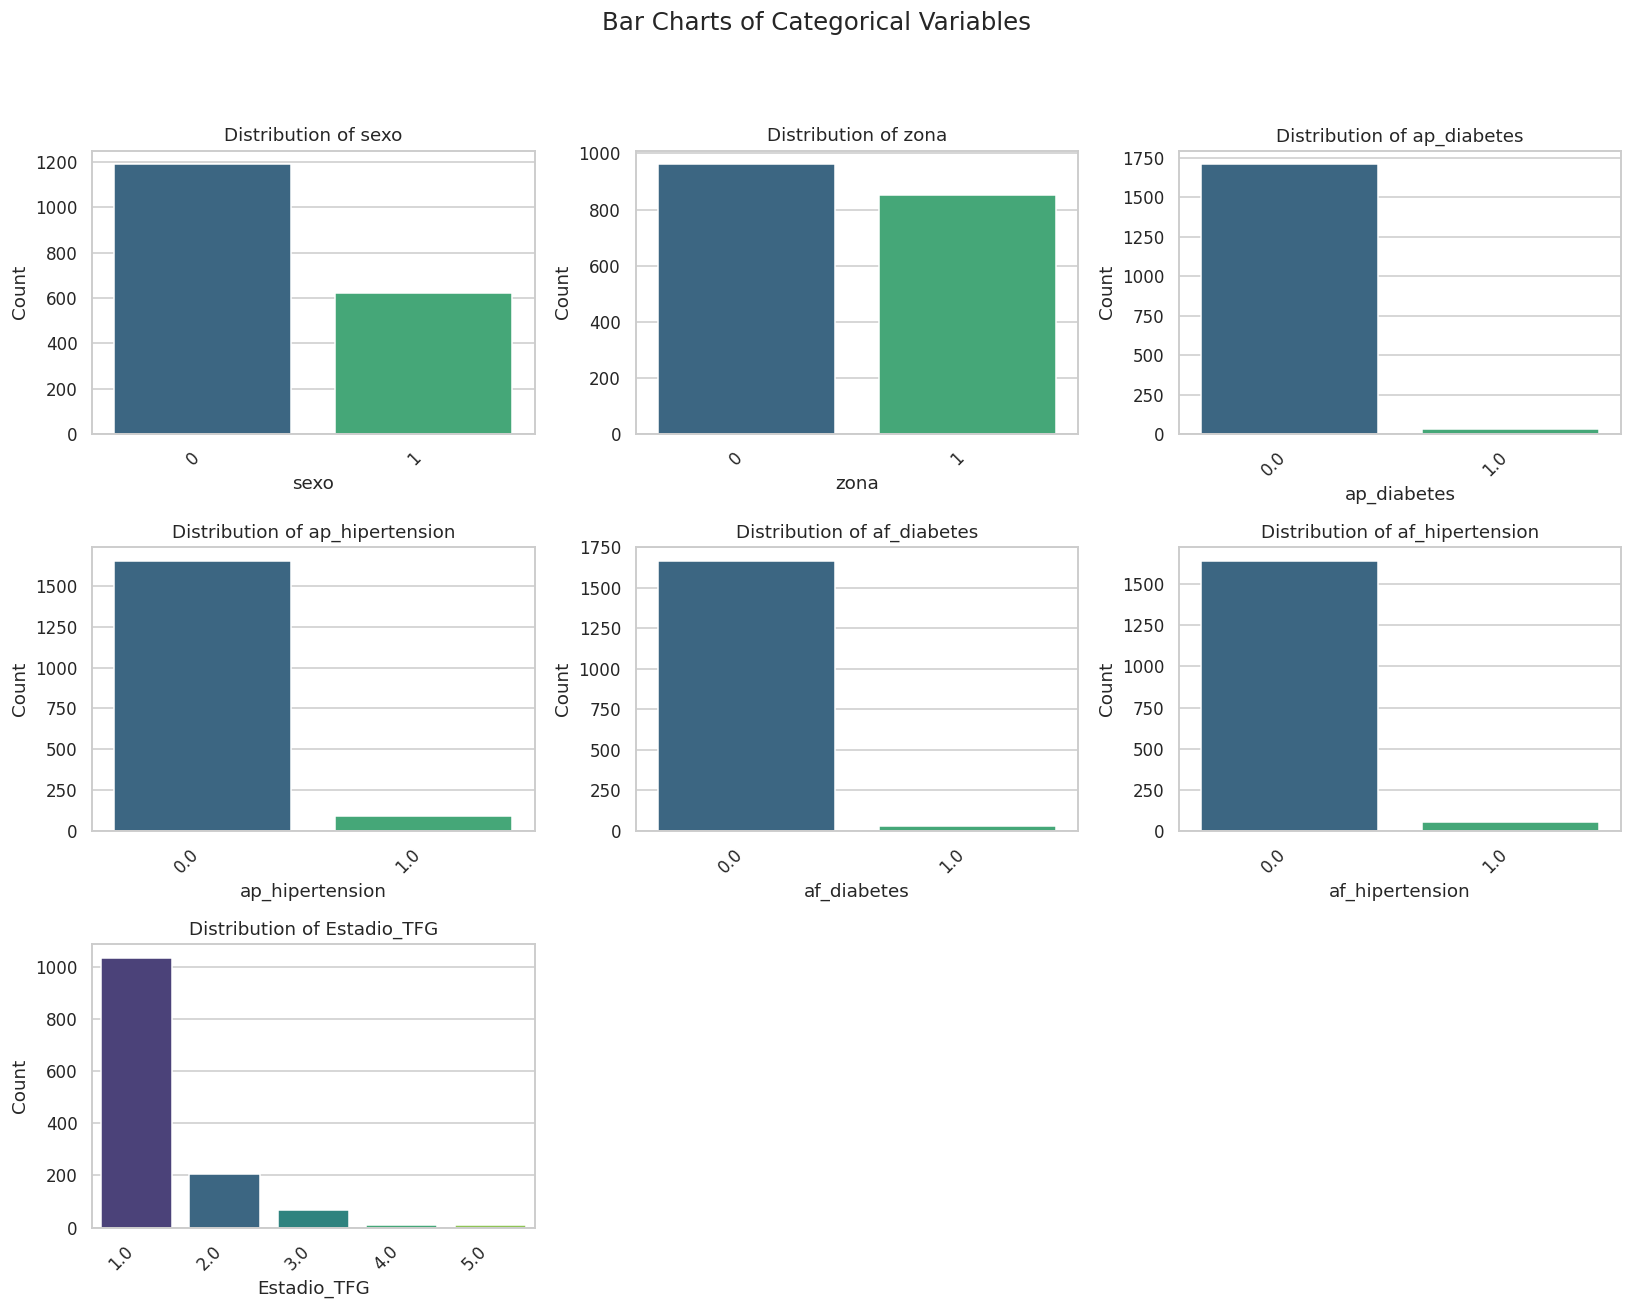

In [12]:
categorical_cols = df.select_dtypes(include='object').columns
potential_categorical_int_cols = [
    'sexo', 'zona', 'ap_diabetes', 'ap_hipertension',
    'af_diabetes', 'af_hipertension', 'Estadio_TFG'
]

# Filter to ensure these columns actually exist in the DataFrame
categorical_int_cols = [col for col in potential_categorical_int_cols if col in df.columns]

all_categorical_cols = list(categorical_cols) + categorical_int_cols

if not all_categorical_cols:
    print("No categorical columns found to plot.")
else:
    # Determine a good grid size for subplots
    num_plots = len(all_categorical_cols)
    num_cols = 3 # Number of columns for the subplot grid
    num_rows = (num_plots + num_cols - 1) // num_cols # Calculate rows needed

    plt.figure(figsize=(num_cols * 5, num_rows * 4))
    plt.suptitle('Bar Charts of Categorical Variables', y=1.02, fontsize=16)

    for i, col in enumerate(all_categorical_cols):
        plt.subplot(num_rows, num_cols, i + 1)
        if col in df.columns:
            # For integer columns treated as categorical, ensure they are treated as such in plotting
            sns.countplot(x=df[col], palette='viridis')
            plt.title(f'Distribution of {col}')
            plt.xlabel(col)
            plt.ylabel('Count')
            plt.xticks(rotation=45, ha='right')
        else:
            print(f"Warning: Column '{col}' not found in DataFrame. Skipping.")

    plt.tight_layout(rect=[0, 0.03, 1, 0.98])
    plt.show()

## Analisis bivariado

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

# Define numerical and categorical variables
vars_num = ['ta_sistolica','ta_diastolica','ldl','hdl','c_total',
            'trigliceridos','glucosa','imc','edad','acido_urico',
            'cigarrillo_cantidad_diaria','alcohol_anos_uso']

vars_cat = ['sexo','ap_diabetes','ap_hipertension','af_diabetes','af_hipertension']

# Filter to ensure these columns actually exist in the DataFrame
vars_num = [v for v in vars_num if v in df.columns]
vars_cat = [v for v in vars_cat if v in df.columns]

# Convert categorical integer columns to object type to ensure proper handling for plotting
for col in vars_cat:
    if col in df.columns:
        df[col] = df[col].astype(object)


print(f"Variables numéricas para el análisis: {', '.join(vars_num)}")
print(f"Variables categóricas para el análisis: {', '.join(vars_cat)}")

Variables numéricas para el análisis: ta_sistolica, ta_diastolica, ldl, hdl, c_total, trigliceridos, glucosa, imc, edad, cigarrillo_cantidad_diaria, alcohol_anos_uso
Variables categóricas para el análisis: sexo, ap_diabetes, ap_hipertension, af_diabetes, af_hipertension


1. Matriz de correlación para variables numéricas

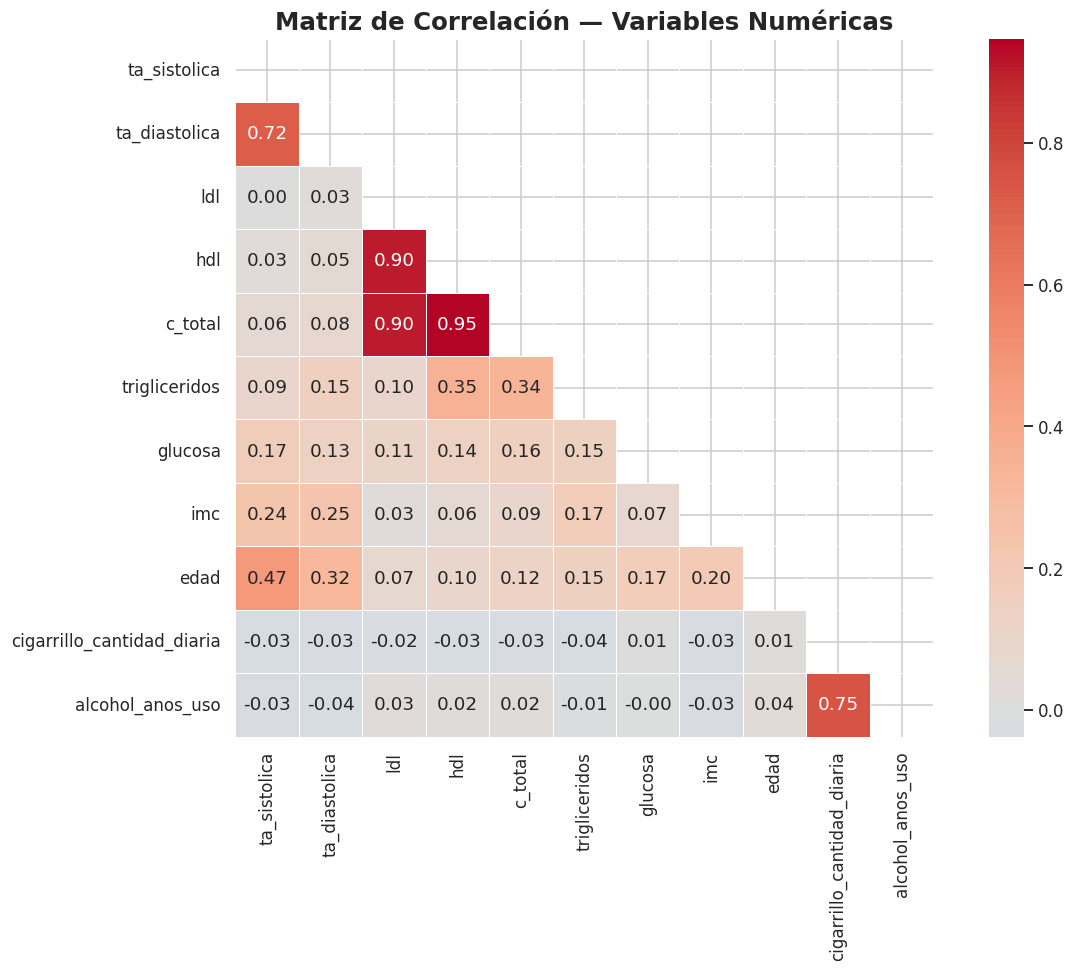

In [14]:
# Calculate correlation matrix for numerical variables
corr = df[vars_num].corr()

# Plotting the heatmap
plt.figure(figsize=(12, 9))
sns.heatmap(corr, mask=np.triu(np.ones_like(corr, dtype=bool)),
            annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Matriz de Correlación — Variables Numéricas', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

2. Coeficientes de correlación de Pearson y p-valores

In [15]:
# Calculate Pearson correlation and p-values for all pairs of numerical variables
pearson_results = []
for v1, v2 in combinations(vars_num, 2):
    d = df[[v1, v2]].dropna()
    if len(d) > 1:
        r, p = stats.pearsonr(d[v1], d[v2])
        pearson_results.append({
            'V1': v1,
            'V2': v2,
            'r': round(r,3),
            'p': round(p,5),
            'sig': '***' if p < .001 else '**' if p < .01 else '*' if p < .05 else 'ns'
        })

df_p = pd.DataFrame(pearson_results).sort_values('r', key=abs, ascending=False)
print("Correlaciones de Pearson significativas (p < 0.05):")
display(df_p[df_p['sig'] != 'ns'])

Correlaciones de Pearson significativas (p < 0.05):


,V1,V2,r,p,sig
27,hdl,c_total,0.947,0.00000,***
20,ldl,c_total,0.904,0.00000,***
19,ldl,hdl,0.902,0.00000,***
54,cigarrillo_cantidad_diaria,alcohol_anos_uso,0.750,0.00000,***
0,ta_sistolica,ta_diastolica,0.716,0.00000,***
7,ta_sistolica,edad,0.469,0.00000,***
28,hdl,trigliceridos,0.354,0.00000,***
34,c_total,trigliceridos,0.339,0.00000,***
16,ta_diastolica,edad,0.316,0.00000,***
15,ta_diastolica,imc,0.246,0.00000,***


3. Scatter Plots para las correlaciones numéricas más fuertes

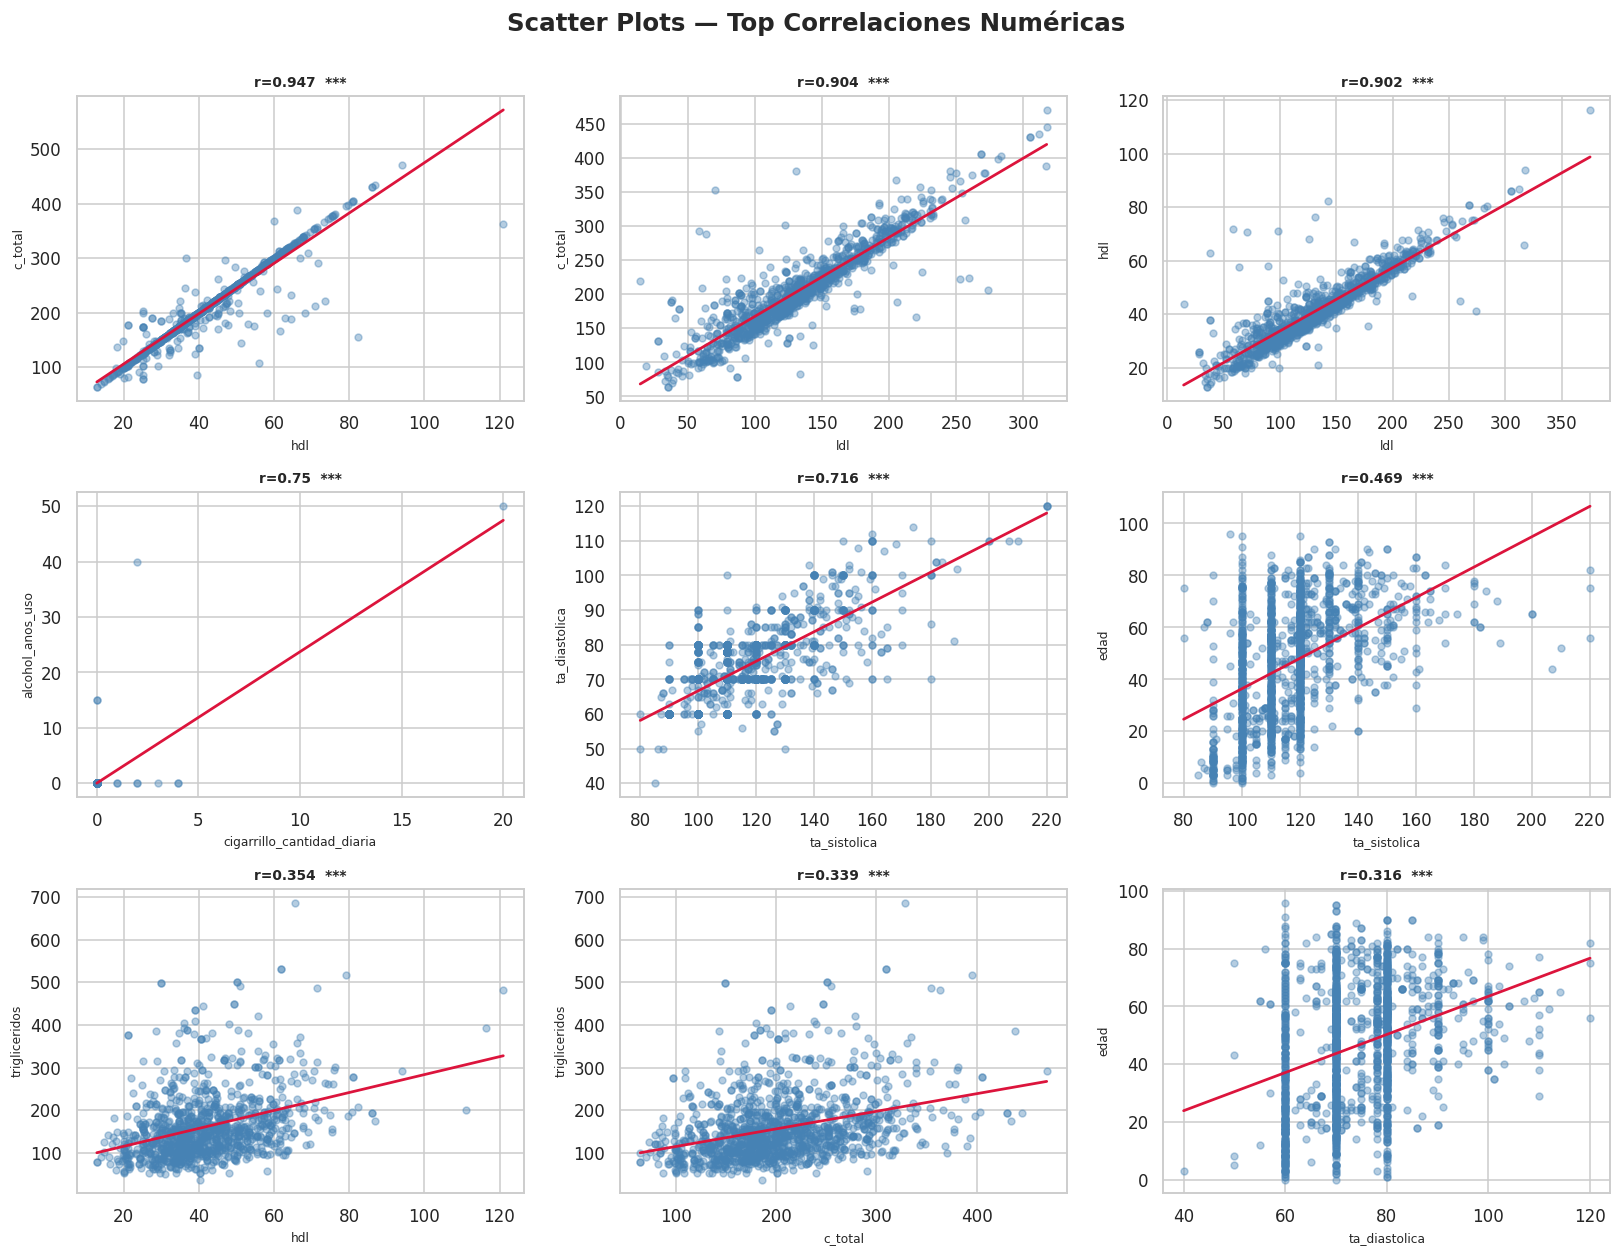

In [16]:
# Select top 9 significant correlations for scatter plots
top_correlations = df_p[df_p['sig'] != 'ns'].head(9)

# Plotting scatter plots
num_plots = len(top_correlations)
if num_plots > 0:
    num_cols = 3
    num_rows = (num_plots + num_cols - 1) // num_cols

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 5, num_rows * 4))
    axes = axes.flatten() if num_rows > 1 or num_cols > 1 else [axes]

    for i, (_, row) in enumerate(top_correlations.iterrows()):
        ax = axes[i]
        v1, v2 = row['V1'], row['V2']
        d = df[[v1, v2]].dropna()

        if not d.empty:
            ax.scatter(d[v1], d[v2], alpha=0.4, s=20, color='steelblue')
            # Add a regression line
            m, b = np.polyfit(d[v1], d[v2], 1)
            x_line = np.linspace(d[v1].min(), d[v1].max(), 100)
            ax.plot(x_line, m*x_line+b, color='crimson', lw=1.8)

            ax.set_xlabel(v1, fontsize=8)
            ax.set_ylabel(v2, fontsize=8)
            ax.set_title(f"r={row['r']}  {row['sig']}", fontsize=9, fontweight='bold')
        else:
            ax.set_visible(False) # Hide empty subplots

    plt.suptitle('Scatter Plots — Top Correlaciones Numéricas', fontsize=16, fontweight='bold')
    plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent overlap
    plt.show()
else:
    print("No hay correlaciones significativas para graficar scatter plots.")

Basado en las graficas obtenidas se concluye que las variables mas representativas de mi dataset son ta_sistolica, ldl, hdl, trigliceridos, edad, glucosa. En cuanto a cigarrillos cantidad diaria y alcohol años de uso, a pesar de que de muestra una excelente correlacion que nos indica que las personas que fuman tambien tienen mas años de consumo de alcohol, no existe una representatividad en sus datos y no superan ni el 10% de variación lo cual hace que sea descartada en las proximas etapas. Por otra parte, en cuanto a la variable c_total muestra una alta correlacion con ldl, lo que se considera logico debido a que c_total la incluye, asi que deben moverse juntas por eso, tambien se considera eliminar la avriable c-total ya que es mas general

4. Mann-Whitney U Test y Boxplots para variables categóricas vs numéricas

Resultados del test de Mann-Whitney U (p < 0.05):


,cat,num,p,sig
8,sexo,edad,0.00000,***
22,ap_hipertension,ta_sistolica,0.00000,***
19,ap_diabetes,edad,0.00000,***
17,ap_diabetes,glucosa,0.00000,***
30,ap_hipertension,edad,0.00000,***
23,ap_hipertension,ta_diastolica,0.00033,***
34,af_diabetes,ta_diastolica,0.00142,**
0,sexo,ta_sistolica,0.00146,**
6,sexo,glucosa,0.00191,**
2,sexo,ldl,0.00369,**


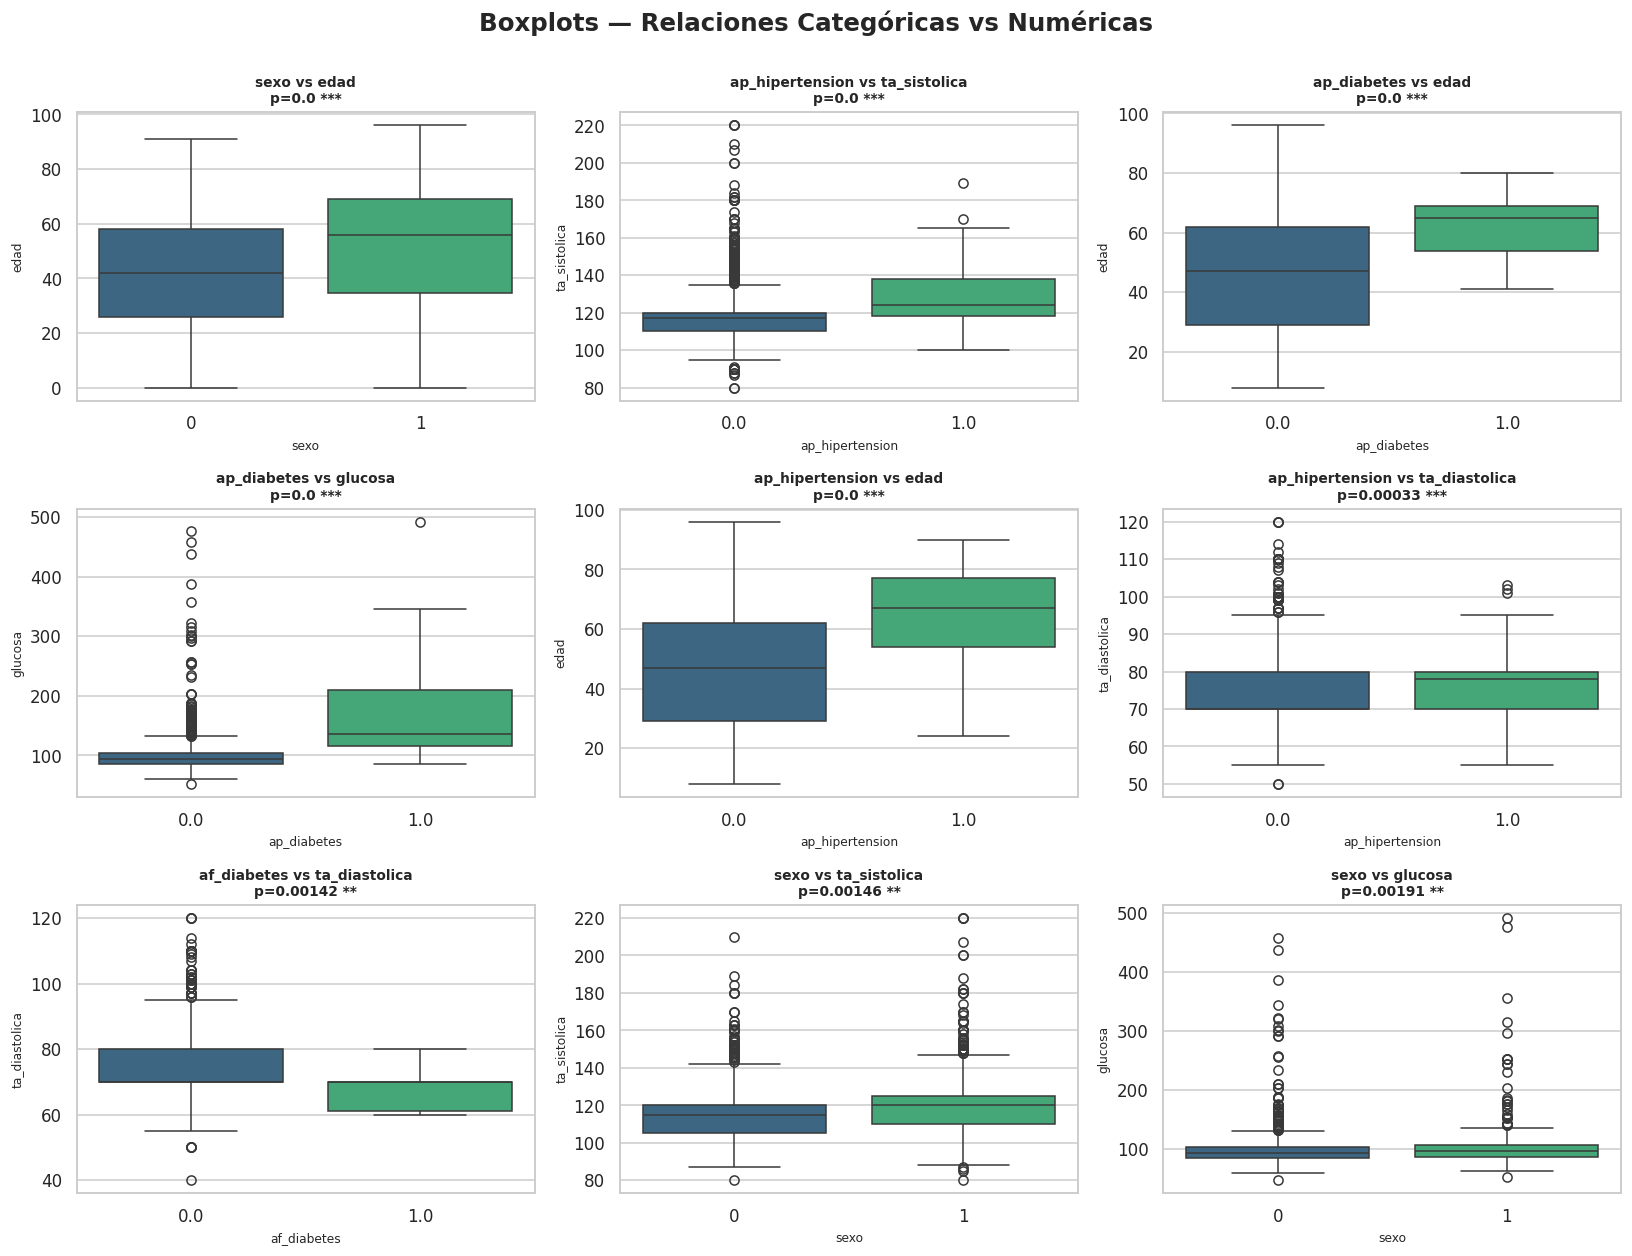

In [17]:
# Perform Mann-Whitney U test and prepare for boxplots
mann_whitney_results = []
for cat_col in vars_cat:
    for num_col in vars_num:
        # Ensure the categorical column is treated as object for grouping
        d = df[[cat_col, num_col]].dropna()

        # Filter to binary categorical variables
        unique_categories = d[cat_col].unique()
        if len(unique_categories) == 2:
            group0 = d[d[cat_col] == unique_categories[0]][num_col]
            group1 = d[d[cat_col] == unique_categories[1]][num_col]

            if len(group0) > 0 and len(group1) > 0: # Ensure both groups have data
                stat, p = stats.mannwhitneyu(group0, group1, alternative='two-sided')
                mann_whitney_results.append({
                    'cat': cat_col,
                    'num': num_col,
                    'p': round(p,5),
                    'sig': '***' if p < .001 else '**' if p < .01 else '*' if p < .05 else 'ns'
                })

df_t = pd.DataFrame(mann_whitney_results).sort_values('p')
print("Resultados del test de Mann-Whitney U (p < 0.05):")
display(df_t[df_t['sig'] != 'ns'])

# Select top 9 significant relationships for boxplots
top_boxplots = df_t[df_t['sig'] != 'ns'].head(9)

# Plotting boxplots
num_plots = len(top_boxplots)
if num_plots > 0:
    num_cols = 3
    num_rows = (num_plots + num_cols - 1) // num_cols

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 5, num_rows * 4))
    axes = axes.flatten() if num_rows > 1 or num_cols > 1 else [axes]

    for i, (_, row) in enumerate(top_boxplots.iterrows()):
        ax = axes[i]
        cat_col, num_col = row['cat'], row['num']
        d = df[[cat_col, num_col]].dropna()

        if not d.empty:
            sns.boxplot(x=cat_col, y=num_col, data=d, ax=ax, palette='viridis')
            ax.set_title(f"{cat_col} vs {num_col}\np={row['p']} {row['sig']}", fontsize=9, fontweight='bold')
            ax.set_xlabel(cat_col, fontsize=8)
            ax.set_ylabel(num_col, fontsize=8)
        else:
            ax.set_visible(False) # Hide empty subplots

    plt.suptitle('Boxplots — Relaciones Categóricas vs Numéricas', fontsize=16, fontweight='bold')
    plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent overlap
    plt.show()
else:
    print("No hay relaciones significativas (categórica vs numérica) para graficar boxplots.")

Perfil lipídico
ldl, hdl y c_total están fuertemente correlacionadas entre sí (r > 0.75). Para el clustering usa solo ldl y hdl para evitar redundancia con c_total
Perfil conductual
cigarrillo_cantidad_diaria y alcohol_anos_uso van juntas (r = 0.75). Representan un perfil de riesgo conductual combinado, incluye ambas.
Diabetes
ap_diabetes separa muy bien la glucosa entre grupos (p = 0.0). Son consistentes y complementarias, incluye las dos.
Hipertensión y edad
ap_hipertension y edad muestran diferencias claras entre grupos. Los hipertensos son significativamente mayores. Ambas son relevantes para el clustering.
Sexo
Diferencia significativamente el acido_urico y la edad. Incluirlo como variable de ajuste.

# Segunda limpieza (profunda)

Primero, revisamos que cantidad de datos hay nulos por variable y a partir de alli se escoge el metodo adecuado para la imputación

In [18]:
import pandas as pd

df = pd.read_csv("datos_limpios.csv", sep=';')

pct_nulos = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(pct_nulos[pct_nulos > 0].round(1))

ldl                           38.7
hdl                           37.2
Estadio_TFG                   26.7
creatinina                    26.2
TFG                           26.0
trigliceridos                 24.4
c_total                       23.7
glucosa                       12.7
celulas_medias                12.1
hemoglobina                    9.7
plaquetas                      9.5
linfocitos                     9.4
leucocitos                     9.4
granulocitos                   9.4
hematocrito                    8.8
af_diabetes                    6.4
af_hipertension                6.4
ta_sistolica                   6.0
alcohol_anos_uso               5.9
cigarrillo_cantidad_diaria     5.9
ta_diastolica                  5.8
peso                           4.0
ap_diabetes                    3.9
ap_hipertension                3.9
talla                          3.2
imc                            3.0
dtype: float64


Eliminación de variables que no aportan al modelo

In [19]:
#Se elimina id porque no es una variable predictora
df = df.drop(columns=['id'])
print("Columna 'id' eliminada.")


Columna 'id' eliminada.


In [20]:
#Se eimina la variable de colesterol total porque segun el EDA esta altamente correlacionada con
#la variable ldl
df = df.drop(columns=['c_total'])
print("Columna 'c_total' eliminada.")

Columna 'c_total' eliminada.


In [21]:
#Se eliminan las variables cigarrillo_cantidad_diaria y alcohol_anos_uso por su
#baja representatividad en los datos  al igual que ap_diabetes, af_diabetes_af_hipertension
df = df.drop(columns=['cigarrillo_cantidad_diaria', 'alcohol_anos_uso', 'ap_diabetes', 'af_hipertension', 'af_diabetes'], errors='ignore')
print("Columnas 'cigarrillo_cantidad_diaria' ,'alcohol_anos_uso', y af with ap  eliminadas (si existían).")

Columnas 'cigarrillo_cantidad_diaria' ,'alcohol_anos_uso', y af with ap  eliminadas (si existían).


In [22]:
#Se elimina la variable Estadio_TFG debido a que es un predictor directo
df = df.drop(columns=['Estadio_TFG'])
print("Columna 'Estadio_TFG' eliminada.")

Columna 'Estadio_TFG' eliminada.


### KNN imputación

Debido a que la cantidad de datos no supera el 40% no se elimina ninguna variable, y se opta por usar el metodo del KNN, KNN (K-Nearest Neighbors) para imputación significa que para rellenar un valor nulo, busca los K pacientes más similares (por las otras variables) y usa el promedio de sus valores.

Por ejemplo, en el caso de las variable ¿s (ldl, hdl, trigliceridos) ya que esas variables están relacionadas entre sí (el perfil lipídico es coherente entre variables).

In [23]:
from sklearn.impute import KNNImputer
#  1. KNN IMPUTACIÓN
# KNNImputer solo trabaja con numéricas
cols_numericas = df.select_dtypes(include=[np.number]).columns.tolist()

imputer = KNNImputer(n_neighbors=5)
df[cols_numericas] = imputer.fit_transform(df[cols_numericas])

print("\n Imputación KNN completada")
print(f"Nulos restantes: {df.isnull().sum().sum()}")


 Imputación KNN completada
Nulos restantes: 0


### Winsorizacion

In [24]:
def winsorizar_expert(df_input):
    df = df_input.copy()

    limites_expertos = {
        'c_total':       (0,     550.0),
        'creatinina':    (0,     2.0),
        'celulas_medias':(0,     20.0),
        'glucosa':       (25.0,  492.0),
        'hdl':           (0,     120.0),
        'hematocrito':   (14.0,  63.0),
        'hemoglobina':   (7.0,   21.0),
        'ldl':           (0,     404.6),
        'trigliceridos': (0,     420.0),
        'edad':          (6,     110),
        'ta_sistolica':  (60.5,  220.0),
        'ta_diastolica': (40.0,  120.0),
        'peso':          (9.0,   170.0),
        'talla':         (1.27,  1.97),
        'imc':           (4.51,  60.0),
        'TFG':           (11.47, 197.39)
    }

    for var, (l_inf, l_sup) in limites_expertos.items():
        if var in df.columns:
            df[var] = df[var].clip(lower=l_inf, upper=l_sup)

    return df

In [25]:
# Aplicamos la winsorización con los límites definidos por expertos
df = winsorizar_expert(df)
print("Winsorización aplicada al DataFrame.")

Winsorización aplicada al DataFrame.


# División train/test

In [26]:
from sklearn.model_selection import train_test_split

# Para clustering (aprendizaje no supervisado), la división se hace sobre todas las características (df).
# 'X' representará el conjunto completo de características para el clustering.
X = df.copy()

X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

print(f"Tamaño del conjunto de entrenamiento: {X_train.shape[0]} filas, {X_train.shape[1]} columnas")
print(f"Tamaño del conjunto de prueba: {X_test.shape[0]} filas, {X_test.shape[1]} columnas")

Tamaño del conjunto de entrenamiento: 1450 filas, 22 columnas
Tamaño del conjunto de prueba: 363 filas, 22 columnas


# Estandarizacion con Z-score

Ahora, se hace estandarizacion con StandardScaler ya que esta usa el emtodo z-score para escalar datos y transformar la media en 0 y la desviacion en 1. Este metodo fue escogido porque es mejor en aplicaicones clinicas

In [27]:
from sklearn.preprocessing import StandardScaler

# Inicializar el StandardScaler
scaler = StandardScaler()

# Ajustar el scaler a los datos de entrenamiento y transformar los datos de entrenamiento
X_train_scaled = scaler.fit_transform(X_train)

# Transformar los datos de prueba usando el mismo scaler ajustado
X_test_scaled = scaler.transform(X_test)

# Convertir los arrays escalados de nuevo a DataFrames para mantener las etiquetas de las columnas
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Datos de entrenamiento estandarizados (primeras 5 filas):")
display(X_train_scaled.head())

print("\nDatos de prueba estandarizados (primeras 5 filas):")
display(X_test_scaled.head())

Datos de entrenamiento estandarizados (primeras 5 filas):


,creatinina,celulas_medias,glucosa,granulocitos,hdl,hematocrito,hemoglobina,ldl,leucocitos,linfocitos,...,edad,sexo,zona,ap_hipertension,ta_sistolica,ta_diastolica,peso,talla,imc,TFG
806,-0.282701,-0.011986,-0.636972,0.026347,-0.538593,-0.903445,-1.086855,-1.199392,0.085700,-0.198568,...,-0.999751,-0.727692,-0.948891,-0.226907,-0.393694,-1.381060,-0.461475,0.0,0.041746,0.606241
1304,0.161894,0.061346,-0.452394,0.170748,-0.555806,-0.124979,-0.202249,-0.389090,-0.269123,-0.509836,...,0.034497,-0.727692,1.053862,-0.226907,-1.001699,-1.381060,0.123097,0.0,0.474405,0.098995
864,-0.208602,2.627955,0.408970,-0.031414,-0.060066,1.718759,1.509891,-0.403390,0.308495,-0.509836,...,-0.153548,1.374207,-0.948891,-0.226907,0.214311,0.619896,-0.911145,0.0,-1.195860,0.076953
1747,0.458290,-1.038629,-0.575446,0.084107,1.354859,1.309039,1.509891,1.426938,-0.186606,-0.150680,...,0.598632,1.374207,-0.948891,-0.226907,0.822317,-0.380582,0.245151,0.0,-0.378839,-0.412240
907,0.458290,-1.038629,0.931941,-0.118055,0.907316,-0.739558,-0.915641,1.341142,0.528540,0.268335,...,1.115755,-0.727692,-0.948891,-0.226907,3.862343,1.220183,-2.067441,0.0,-2.163809,-1.225695



Datos de prueba estandarizados (primeras 5 filas):


,creatinina,celulas_medias,glucosa,granulocitos,hdl,hematocrito,hemoglobina,ldl,leucocitos,linfocitos,...,edad,sexo,zona,ap_hipertension,ta_sistolica,ta_diastolica,peso,talla,imc,TFG
990,-1.023691,1.894638,-0.790787,-0.349097,0.132722,-0.534698,-0.630284,0.507008,-0.159100,0.268335,...,1.397823,-0.727692,-0.948891,-0.226907,-0.393694,-1.381060,-1.303001,0.0,-1.155613,-0.292583
1084,1.569775,-1.038629,-0.175527,-0.002533,0.270428,-0.329838,-0.416267,0.573738,0.060945,0.028898,...,1.068744,1.374207,-0.948891,-0.226907,-0.393694,-0.380582,-0.076043,0.0,0.023635,-1.456961
1523,0.458290,1.894638,1.301097,-0.089174,-0.194329,-0.329838,-0.416267,0.039893,0.693573,-0.270399,...,1.350812,1.374207,-0.948891,-0.226907,-0.393694,-1.080917,-0.397236,0.0,-0.650508,-0.778557
1137,-0.282701,-0.671971,-0.267816,0.112988,0.063869,-0.329838,-0.416267,0.259151,0.666068,-0.270399,...,0.316564,-0.727692,-0.948891,-0.226907,-0.393694,-0.380582,-0.076043,0.0,-0.280233,-0.190770
1389,1.569775,-0.305313,-0.224748,0.517311,0.106902,-1.558996,-1.843050,-0.192711,-0.214111,-1.168287,...,1.397823,-0.727692,1.053862,4.407101,-0.393694,0.419801,-0.397236,0.0,-0.650508,-2.140613


reduccion de dimensionalidad

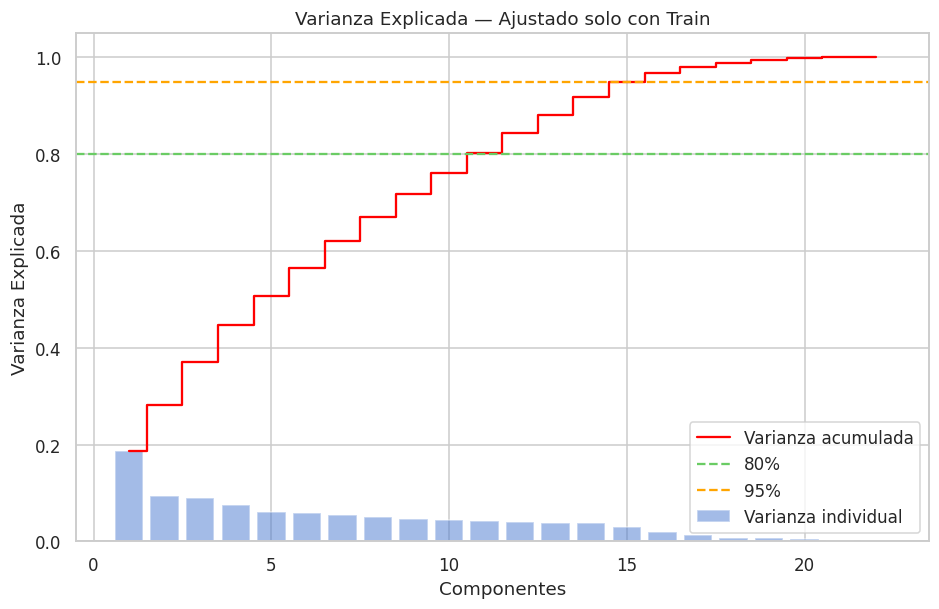

Componentes: 1 | Varianza acumulada: 18.67%
Componentes: 2 | Varianza acumulada: 28.10%
Componentes: 3 | Varianza acumulada: 37.07%
Componentes: 4 | Varianza acumulada: 44.61%
Componentes: 5 | Varianza acumulada: 50.67%
Componentes: 6 | Varianza acumulada: 56.49%
Componentes: 7 | Varianza acumulada: 62.04%
Componentes: 8 | Varianza acumulada: 67.00%
Componentes: 9 | Varianza acumulada: 71.72%
Componentes: 10 | Varianza acumulada: 76.09%
Componentes: 11 | Varianza acumulada: 80.34%
Componentes: 12 | Varianza acumulada: 84.35%
Componentes: 13 | Varianza acumulada: 88.15%
Componentes: 14 | Varianza acumulada: 91.87%
Componentes: 15 | Varianza acumulada: 94.93%
Componentes: 16 | Varianza acumulada: 96.82%
Componentes: 17 | Varianza acumulada: 98.08%
Componentes: 18 | Varianza acumulada: 98.78%
Componentes: 19 | Varianza acumulada: 99.39%
Componentes: 20 | Varianza acumulada: 99.84%
Componentes: 21 | Varianza acumulada: 100.00%
Componentes: 22 | Varianza acumulada: 100.00%


In [28]:
from sklearn.decomposition import PCA

pca_exp = PCA()
pca_exp.fit(X_train_scaled)

varianza_acum = np.cumsum(pca_exp.explained_variance_ratio_)

plt.figure(figsize=(10, 6))
plt.bar(range(1, len(pca_exp.explained_variance_ratio_) + 1),
        pca_exp.explained_variance_ratio_, alpha=0.5, label='Varianza individual')
plt.step(range(1, len(varianza_acum) + 1), varianza_acum,
         where='mid', color='red', label='Varianza acumulada')
plt.axhline(y=0.80, color='g', linestyle='--', label='80%')
plt.axhline(y=0.95, color='orange', linestyle='--', label='95%')
plt.xlabel('Componentes')
plt.ylabel('Varianza Explicada')
plt.title('Varianza Explicada — Ajustado solo con Train')
plt.legend()
plt.grid(True)
plt.show()

for i, v in enumerate(varianza_acum):
    print(f'Componentes: {i+1} | Varianza acumulada: {v*100:.2f}%')

In [29]:
N_COMPONENTS = 11  # ajusta según el scree plot

pca_final = PCA(n_components=N_COMPONENTS)
X_train_pca = pca_final.fit_transform(X_train_scaled)
X_test_pca  = pca_final.transform(X_test_scaled)

print(f' PCA ajustado solo con train')
print(f'  Train PCA shape: {X_train_pca.shape}')
print(f'  Test  PCA shape: {X_test_pca.shape}')

 PCA ajustado solo con train
  Train PCA shape: (1450, 11)
  Test  PCA shape: (363, 11)


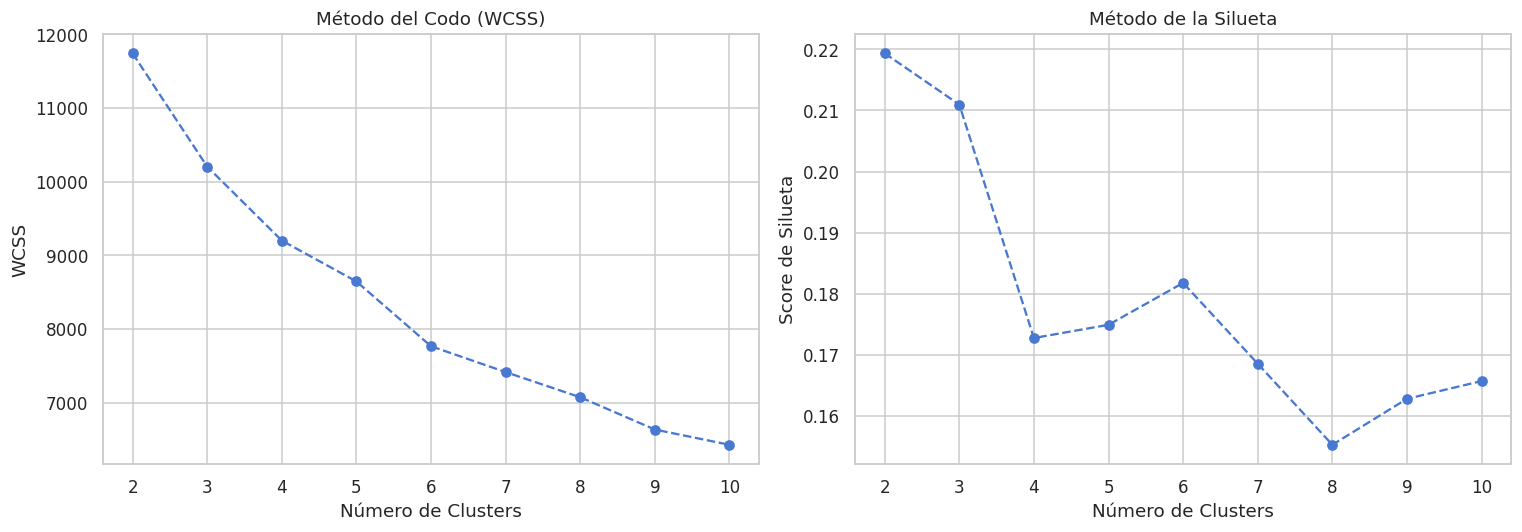

In [30]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

#  1. PCA con 5 componentes
pca = PCA(n_components=5, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)

#  2. Listas para métricas
wcss = []
silhouette_scores = []

#  3. Probar diferentes números de clusters
rango_clusters = range(2, 11)  # silueta no funciona con k=1

for i in rango_clusters:
    km = KMeans(n_clusters=i, init='k-means++', random_state=42)
    labels = km.fit_predict(X_train_pca)

    wcss.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_train_pca, labels))

#  4. Gráficas
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

#  Método del codo (WCSS)
ax[0].plot(rango_clusters, wcss, marker='o', linestyle='--')
ax[0].set_title('Método del Codo (WCSS)')
ax[0].set_xlabel('Número de Clusters')
ax[0].set_ylabel('WCSS')
ax[0].grid(True)

# Silueta
ax[1].plot(rango_clusters, silhouette_scores, marker='o', linestyle='--')
ax[1].set_title('Método de la Silueta')
ax[1].set_xlabel('Número de Clusters')
ax[1].set_ylabel('Score de Silueta')
ax[1].grid(True)

plt.tight_layout()
plt.show()

decision: k=4

In [31]:
# --- SECCIÓN: DETECCIÓN DE ANOMALÍAS ---
from sklearn.ensemble import IsolationForest # Import missing class

# Prepare the full dataset for anomaly detection using the fitted scaler and imputer
# df_modelo is already the feature-engineered DataFrame from previous steps
# Aseguramos que X_full_data tenga las mismas columnas que X_train en el momento de fitting del scaler
X_full_data_for_scaling = df[X_train.columns].values

# Apply the same scaler fitted on the training data
X_full_scaled = scaler.transform(X_full_data_for_scaling)

# Como 'df' (y por lo tanto X_full_scaled) no tiene valores nulos después de la limpieza previa,
# un imputer no es estrictamente necesario. Podemos usar X_full_scaled directamente.
X_scaled = X_full_scaled

# Usamos una contaminación del 1% al 2% para capturar esos casos extremos que vimos
iso_forest = IsolationForest(contamination=0.015, random_state=42)
outliers_preds = iso_forest.fit_predict(X_scaled)

# Guardamos quién es anomalía en el DataFrame original antes de separar
df['Es_Anomalia'] = outliers_preds # Aquí se añade la columna al df original

# Creamos el set de datos "limpio" para el modelo de ARTERY
X_limpio_scaled = X_scaled[outliers_preds == 1]
df_limpio = df[df['Es_Anomalia'] == 1].copy() # Asegurarse de que df_limpio se base en el df original con la columna 'Es_Anomalia'

# Guardamos las anomalías para análisis clínico separado
df_alertas_criticas = df[df['Es_Anomalia'] == -1].copy()

print(f"Pacientes con riesgo estándar: {len(df_limpio)}")
print(f"Pacientes con alertas críticas (Anomalías): {len(df_alertas_criticas)}")

# --- SECCIÓN: CLUSTERING SOBRE DATOS LIMPIOS ---
kmeans_definitivo = KMeans(n_clusters=3, random_state=42, n_init=10)
df_limpio['Cluster_Final'] = kmeans_definitivo.fit_predict(X_limpio_scaled)

Pacientes con riesgo estándar: 1785
Pacientes con alertas críticas (Anomalías): 28


In [32]:
X_train_pca = pca_final.transform(X_train_scaled)
X_test_pca = pca_final.transform(X_test_scaled)

kmeans_final = KMeans(n_clusters=3, init='k-means++', random_state=42)
kmeans_final.fit(X_train_pca)  # fit SOLO en train

y_train = kmeans_final.labels_
y_test  = kmeans_final.predict(X_test_pca)  # predict, no fit

print(' K-Means entrenado solo con datos de train')
print(f'\nDistribución en TRAIN:')
for c, n in zip(*np.unique(y_train, return_counts=True)):
    print(f'  Cluster {c}: {n} pacientes ({n/len(y_train)*100:.1f}%)')

print(f'\nDistribución en TEST:')
for c, n in zip(*np.unique(y_test, return_counts=True)):
    print(f'  Cluster {c}: {n} pacientes ({n/len(y_test)*100:.1f}%)')

 K-Means entrenado solo con datos de train

Distribución en TRAIN:
  Cluster 0: 401 pacientes (27.7%)
  Cluster 1: 429 pacientes (29.6%)
  Cluster 2: 620 pacientes (42.8%)

Distribución en TEST:
  Cluster 0: 101 pacientes (27.8%)
  Cluster 1: 106 pacientes (29.2%)
  Cluster 2: 156 pacientes (43.0%)


In [33]:
df_train = X_train.copy()
df_train['Cluster'] = y_train

# Define numerical variables for the profile
variables_numericas = X_train.select_dtypes(include=np.number).columns

perfil = df_train.groupby('Cluster')[variables_numericas].mean().round(2)
print('=== PERFIL CLÍNICO POR CLUSTER ===')
print(perfil.T)

=== PERFIL CLÍNICO POR CLUSTER ===
Cluster                  0          1          2
creatinina            0.95       0.65       0.52
celulas_medias        4.12       3.14       4.13
glucosa             105.02     106.38      91.65
granulocitos         60.89      66.15      62.39
hdl                  37.66      53.16      35.35
hematocrito          41.72      43.64      40.14
hemoglobina          13.94      14.51      13.42
ldl                 114.36     170.41     112.92
leucocitos         7538.94    7647.11    8024.18
linfocitos           35.09      35.19      36.02
plaquetas        287813.37  297082.77  294926.13
trigliceridos       163.71     187.55     130.71
edad                 64.96      51.02      28.55
sexo                  0.65       0.29       0.19
zona                  0.50       0.49       0.45
ap_hipertension       0.15       0.01       0.01
ta_sistolica        126.45     119.28     108.09
ta_diastolica        77.88      76.43      69.35
peso                 69.45      73

## random forest

In [34]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Se añade el parámetro class_weight='balanced'
# Esto ajustará automáticamente los pesos de forma inversamente proporcional a las frecuencias de las clases.
# ── Parámetros ajustados para reducir overfitting ─────────────
rf = RandomForestClassifier(
    n_estimators=150,        # más árboles = más estabilidad
    max_depth=8,             # más restrictivo que 8
    min_samples_leaf=15,     # cada hoja necesita mínimo 10 obs
    min_samples_split=40,    # mínimo para hacer cualquier split
    max_features="sqrt",     # solo raíz de features por split
    max_samples=0.8,         # cada árbol ve solo 80% del train
    class_weight="balanced", # si tus clusters están desbalanceados
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_pca, y_train)

y_test_pred = rf.predict(X_test_pca)

train_acc = rf.score(X_train_pca, y_train)
test_acc  = rf.score(X_test_pca,  y_test)

print(f'Train: {train_acc:.4f} | Test: {test_acc:.4f} | Gap: {abs(train_acc - test_acc):.4f}')

print(classification_report(
    y_test, y_test_pred,
    target_names=['Cardio-renal (0)', 'Cardiovascular inflamatorio(1)', 'Bajo riesgo (2)']
))

Train: 0.9545 | Test: 0.9284 | Gap: 0.0261
                                precision    recall  f1-score   support

              Cardio-renal (0)       0.88      0.91      0.89       101
Cardiovascular inflamatorio(1)       0.91      0.92      0.92       106
               Bajo riesgo (2)       0.98      0.94      0.96       156

                      accuracy                           0.93       363
                     macro avg       0.92      0.93      0.92       363
                  weighted avg       0.93      0.93      0.93       363



Matriz de confusion

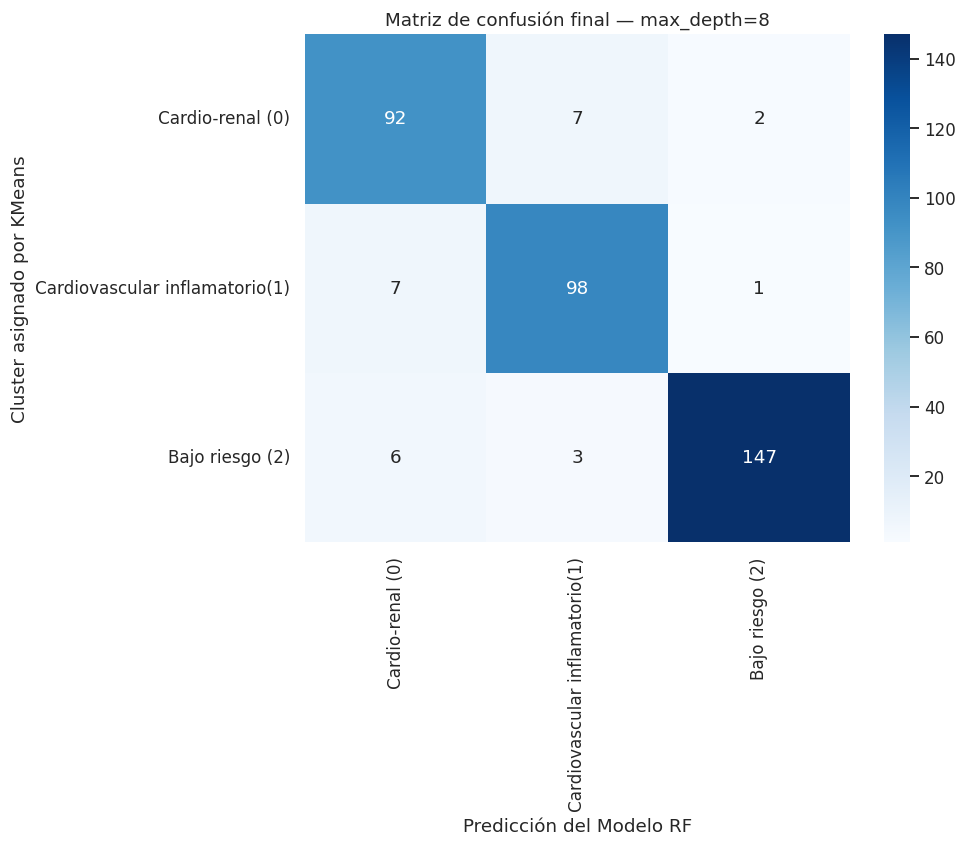

In [35]:
from sklearn.metrics import confusion_matrix

y_test_pred = rf.predict(X_test_pca)

cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Cardio-renal (0)', 'Cardiovascular inflamatorio(1)', 'Bajo riesgo (2)'],
            yticklabels=['Cardio-renal (0)', 'Cardiovascular inflamatorio(1)', 'Bajo riesgo (2)'])
plt.xlabel('Predicción del Modelo RF')
plt.ylabel('Cluster asignado por KMeans')
plt.title('Matriz de confusión final — max_depth=8')
plt.show()

Analissi de sensibilidad

In [36]:
for depth in [12, 10, 8, 5]:
    rf_test = RandomForestClassifier(n_estimators=100, max_depth=depth, random_state=42)
    rf_test.fit(X_train_pca, y_train)
    tr  = rf_test.score(X_train_pca, y_train)
    te  = rf_test.score(X_test_pca,  y_test)
    gap = abs(tr - te)
    print(f'max_depth={str(depth):>4} | Train: {tr:.4f} | Test: {te:.4f} | Gap: {gap:.4f}')

max_depth=  12 | Train: 1.0000 | Test: 0.9394 | Gap: 0.0606
max_depth=  10 | Train: 1.0000 | Test: 0.9394 | Gap: 0.0606
max_depth=   8 | Train: 0.9993 | Test: 0.9366 | Gap: 0.0627
max_depth=   5 | Train: 0.9676 | Test: 0.9201 | Gap: 0.0475


verificacion de posible overfitting con validacion cruzada

In [37]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

train_acc = rf.score(X_train_pca, y_train)
test_acc  = rf.score(X_test_pca,  y_test)
gap       = abs(train_acc - test_acc)

print('=== VERIFICACIÓN DE OVERFITTING ===')
print(f'Precisión Train: {train_acc:.4f}')
print(f'Precisión Test:  {test_acc:.4f}')
print(f'Gap:             {gap:.4f}  {" OK" if gap < 0.05 else " Revisar"}')

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X_train_pca, y_train, cv=skf, scoring='accuracy')

print('=== VALIDACIÓN CRUZADA — max_depth=5 ===')
print(f'Puntajes por fold: {cv_scores.round(4)}')
print(f'Media:             {np.mean(cv_scores):.4f}')
print(f'Std:               {np.std(cv_scores):.4f}')

=== VERIFICACIÓN DE OVERFITTING ===
Precisión Train: 0.9545
Precisión Test:  0.9284
Gap:             0.0261   OK
=== VALIDACIÓN CRUZADA — max_depth=5 ===
Puntajes por fold: [0.9414 0.9448 0.9138 0.9172 0.9379]
Media:             0.9310
Std:               0.0129


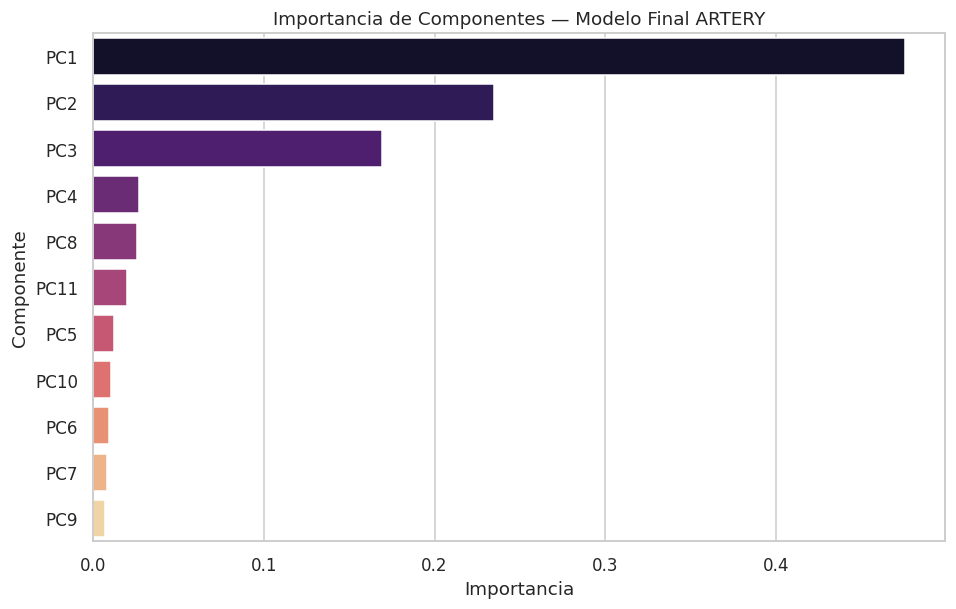

In [38]:
importances = rf.feature_importances_
feature_names = [f'PC{i+1}' for i in range(X_train_pca.shape[1])]
feat_df = pd.DataFrame({'Componente': feature_names, 'Importancia': importances})
feat_df = feat_df.sort_values('Importancia', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Componente', data=feat_df, palette='magma')
plt.title('Importancia de Componentes — Modelo Final ARTERY')
plt.show()

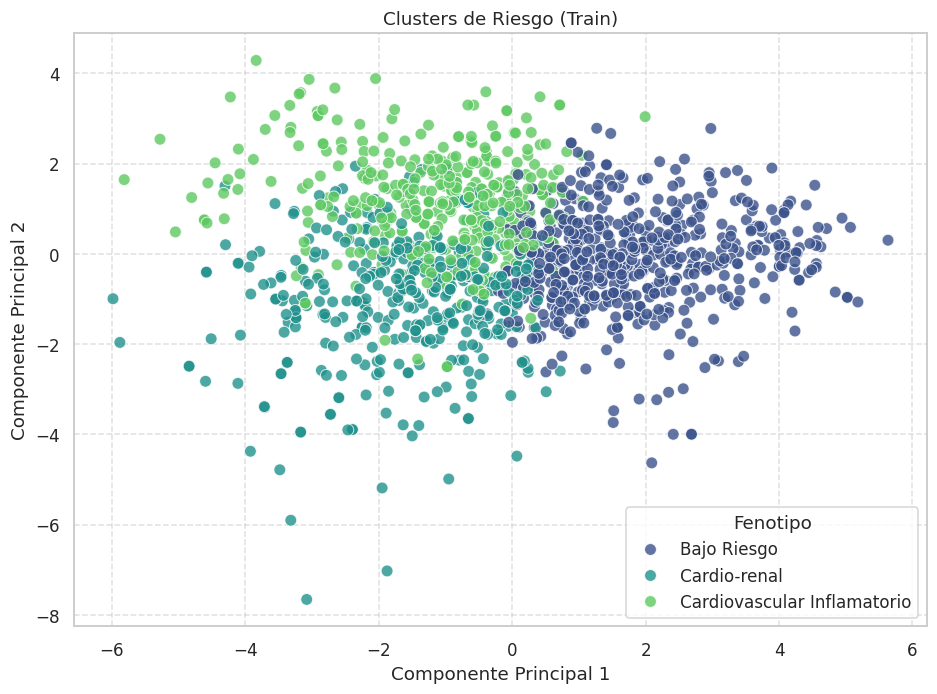

In [39]:
import pandas as pd
df_pca_plot = pd.DataFrame(X_train_pca[:, :2], columns=['PC1', 'PC3'])
df_pca_plot['Cluster'] = y_train.astype(str).tolist()
df_pca_plot['Cluster'] = df_pca_plot['Cluster'].map({
    '0': 'Cardio-renal',
    '1': 'Cardiovascular Inflamatorio',
    '2': 'Bajo Riesgo'
})

plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC3', hue='Cluster', data=df_pca_plot,
                palette='viridis', s=60, alpha=0.8)
plt.title('Clusters de Riesgo (Train)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Fenotipo')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

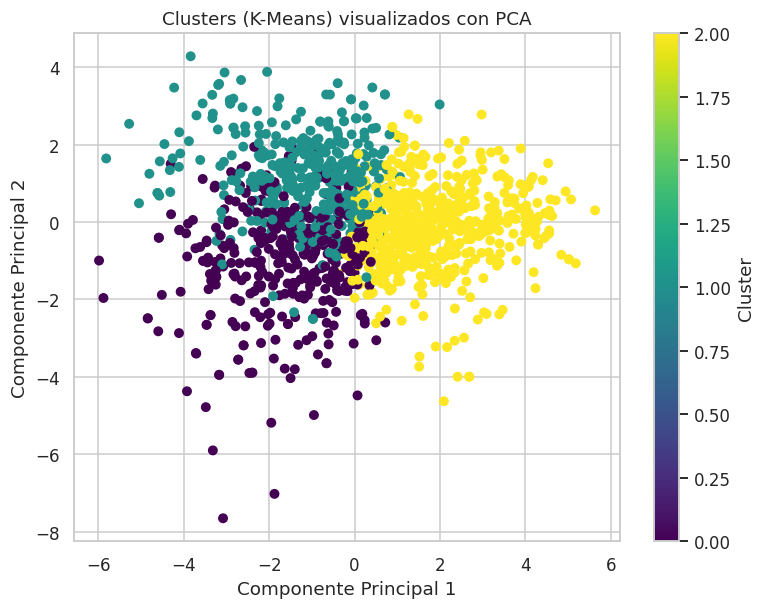

In [40]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reducir a 2 dimensiones
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)

# Graficar
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y_train, cmap='viridis', s=30)

plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('Clusters (K-Means) visualizados con PCA')
plt.colorbar(label='Cluster')
plt.show()

### Perfil clínico por Cluster de K-Means

In [41]:
df_train = X_train.copy()
df_train['Cluster'] = y_train

# Define numerical variables for the profile
variables_numericas = X_train.select_dtypes(include=np.number).columns

perfil = df_train.groupby('Cluster')[variables_numericas].mean().round(2)
print('=== PERFIL CLÍNICO POR CLUSTER ===')
print(perfil.T)

=== PERFIL CLÍNICO POR CLUSTER ===
Cluster                  0          1          2
creatinina            0.95       0.65       0.52
celulas_medias        4.12       3.14       4.13
glucosa             105.02     106.38      91.65
granulocitos         60.89      66.15      62.39
hdl                  37.66      53.16      35.35
hematocrito          41.72      43.64      40.14
hemoglobina          13.94      14.51      13.42
ldl                 114.36     170.41     112.92
leucocitos         7538.94    7647.11    8024.18
linfocitos           35.09      35.19      36.02
plaquetas        287813.37  297082.77  294926.13
trigliceridos       163.71     187.55     130.71
edad                 64.96      51.02      28.55
sexo                  0.65       0.29       0.19
zona                  0.50       0.49       0.45
ap_hipertension       0.15       0.01       0.01
ta_sistolica        126.45     119.28     108.09
ta_diastolica        77.88      76.43      69.35
peso                 69.45      73

## Clustering con KMeans

Primero, aplicaremos el algoritmo de KMeans. Para elegir el número óptimo de clusters (k), utilizaremos el **Método del Codo** y el **Coeficiente de Silueta**.

## Clustering con Gaussian Mixture Models (GMM)

Gaussian Mixture Models (GMM) son algoritmos de clustering probabilísticos que asumen que los puntos de datos se generan a partir de una mezcla de un número finito de distribuciones Gaussianas (normales) con parámetros desconocidos. A diferencia de K-Means, GMMs pueden manejar clusters de formas complejas y asignar probabilidades de pertenencia a cada cluster.

Para determinar el número óptimo de componentes (clusters) para GMM, podemos utilizar criterios de información como el **Criterio de Información Bayesiano (BIC)** y el **Criterio de Información de Akaike (AIC)**. El modelo con el BIC o AIC más bajo es generalmente preferido, ya que equilibra la bondad de ajuste del modelo con la complejidad del mismo.

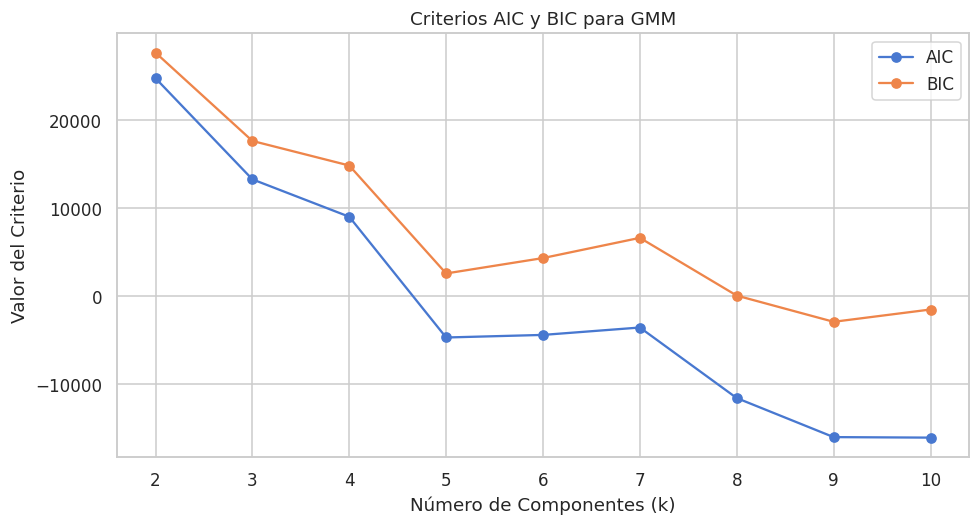

In [42]:
from sklearn.mixture import GaussianMixture

# Definir un rango de k (número de componentes) para evaluar
k_range_gmm = range(2, 11) # Evaluar de 2 a 10 componentes

aic_scores = []
bic_scores = []

for k in k_range_gmm:
    gmm = GaussianMixture(n_components=k, random_state=42, n_init=10)
    gmm.fit(X_train_scaled)
    aic_scores.append(gmm.aic(X_train_scaled))
    bic_scores.append(gmm.bic(X_train_scaled))

# Visualizar AIC y BIC
plt.figure(figsize=(10, 5))

plt.plot(k_range_gmm, aic_scores, marker='o', label='AIC')
plt.plot(k_range_gmm, bic_scores, marker='o', label='BIC')
plt.title('Criterios AIC y BIC para GMM')
plt.xlabel('Número de Componentes (k)')
plt.ylabel('Valor del Criterio')
plt.legend()
plt.grid(True)
plt.show()

In [43]:
gmm = GaussianMixture(n_components=3, random_state=42)
clusters = gmm.fit_predict(X_train_scaled)

### Visualización de Clusters GMM con PCA
Para entender mejor la separación de los clusters identificados por el GMM, visualizaremos los datos reducidos a dos componentes principales (PCA) y coloreados según el cluster asignado.

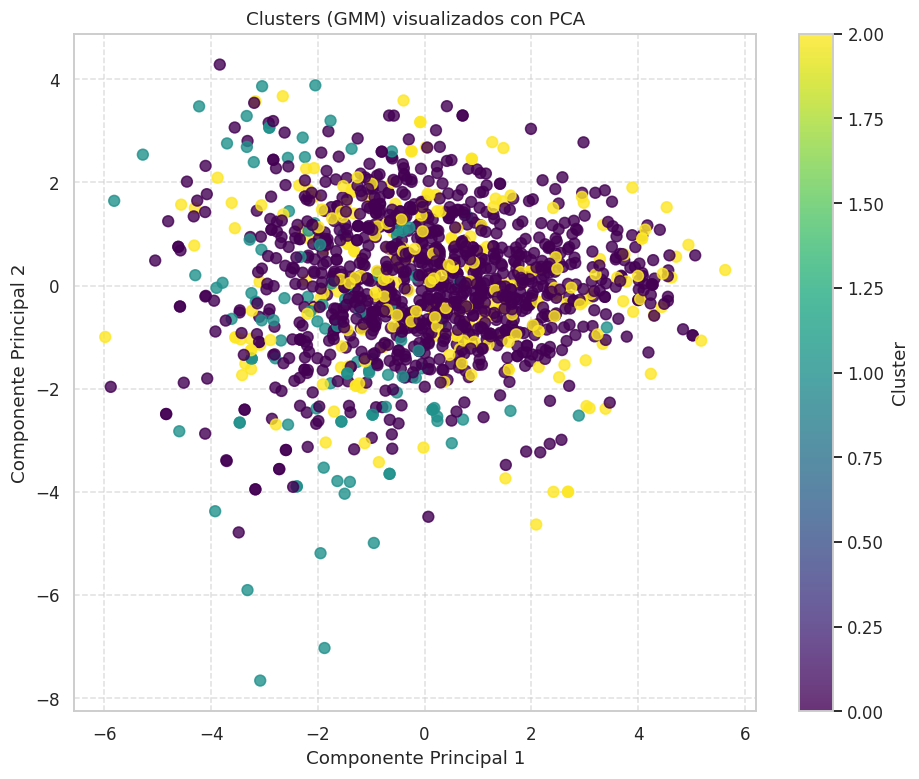

In [44]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reducir a 2 dimensiones para visualización
pca_gmm = PCA(n_components=2)
X_pca_gmm = pca_gmm.fit_transform(X_train_scaled)

# Graficar los clusters de GMM en el espacio PCA
plt.figure(figsize=(10, 8))
plt.scatter(X_pca_gmm[:, 0], X_pca_gmm[:, 1], c=clusters, cmap='viridis', s=50, alpha=0.8)
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('Clusters (GMM) visualizados con PCA')
plt.colorbar(label='Cluster')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Perfil Clínico por Cluster GMM
Ahora, generaremos un perfil clínico para cada uno de los clusters identificados por el Modelo de Mezcla Gaussiana, mostrando los valores medios de las variables numéricas dentro de cada cluster. Esto nos permitirá interpretar y caracterizar cada grupo de pacientes.

In [45]:
df_train_gmm = X_train.copy()
df_train_gmm['Cluster'] = clusters

# Define numerical variables for the profile
variables_numericas_gmm = df_train_gmm.select_dtypes(include=np.number).columns.drop('Cluster')

perfil_gmm = df_train_gmm.groupby('Cluster')[variables_numericas_gmm].mean().round(2)
print('=== PERFIL CLÍNICO POR CLUSTER GMM ===')
print(perfil_gmm.T)

=== PERFIL CLÍNICO POR CLUSTER GMM ===
Cluster                  0          1          2
creatinina            0.67       0.81       0.64
celulas_medias        3.80       3.37       4.16
glucosa              96.06     139.72      98.01
granulocitos         61.17      86.45      61.26
hdl                  41.06      45.69      40.23
hematocrito          41.70      41.62      41.26
hemoglobina          13.86      14.02      13.91
ldl                 131.60     123.68     127.93
leucocitos         7634.70    8268.20    8154.68
linfocitos           35.03      33.52      38.28
plaquetas        296131.87  273788.62  291505.26
trigliceridos       152.01     193.11     160.44
edad                 44.08      59.59      44.19
sexo                  0.32       0.46       0.40
zona                  0.47       0.55       0.45
ap_hipertension       0.00       0.65       0.00
ta_sistolica        115.79     125.27     115.63
ta_diastolica        73.59      77.21      73.28
peso                 66.13    

In [46]:
# Calcular las probabilidades de pertenencia a cada cluster para cada punto en X_train_scaled
probabilities = gmm.predict_proba(X_train_scaled)

print("Probabilidades de pertenencia a cada cluster para las primeras 5 muestras:")
print(probabilities[:5].round(3))

# La suma de probabilidades para cada fila (punto de dato) debería ser 1
print("\nSuma de probabilidades por muestra (para las primeras 5):")
print(probabilities[:5].sum(axis=1).round(3))

Probabilidades de pertenencia a cada cluster para las primeras 5 muestras:
[[1. 0. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [1. 0. 0.]]

Suma de probabilidades por muestra (para las primeras 5):
[1. 1. 1. 1. 1.]


PROBAMOS CON XG BOOST

In [47]:
import xgboost as xgb
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

# Inicializar y entrenar el modelo XGBoost
# Usamos `use_label_encoder=False` y `eval_metric='mlogloss'` para evitar warnings y para clasificación multiclase.
xgb_model = xgb.XGBClassifier(
    objective='multi:softmax', # Para clasificación multiclase
    num_class=len(np.unique(y_train)), # Número de clases
    n_estimators=100, # Número de árboles
    learning_rate=0.1, # Tasa de aprendizaje
    max_depth=5, # Profundidad máxima de los árboles
    random_state=42,
    use_label_encoder=False, # Necesario para evitar un warning en versiones recientes
    eval_metric='mlogloss' # Métrica de evaluación para clasificación multiclase
)

xgb_model.fit(X_train_pca, y_train)

# Predicciones en el conjunto de prueba
y_pred_xgb = xgb_model.predict(X_test_pca)

# Evaluación del modelo XGBoost
train_acc_xgb = xgb_model.score(X_train_pca, y_train)
test_acc_xgb  = xgb_model.score(X_test_pca, y_test)

print(f'\n--- XGBoost Model Performance ---\n')
print(f'Train Accuracy: {train_acc_xgb:.4f}')
print(f'Test Accuracy:  {test_acc_xgb:.4f}')
print(f'Gap (Train - Test): {abs(train_acc_xgb - test_acc_xgb):.4f}')

print('\nClassification Report (XGBoost):')
print(classification_report(y_test, y_pred_xgb, target_names=['Cardio-renal (0)', 'Cardiovascular inflamatorio(1)', 'Bajo riesgo (2)']))


--- XGBoost Model Performance ---

Train Accuracy: 1.0000
Test Accuracy:  0.9559
Gap (Train - Test): 0.0441

Classification Report (XGBoost):
                                precision    recall  f1-score   support

              Cardio-renal (0)       0.92      0.95      0.94       101
Cardiovascular inflamatorio(1)       0.95      0.93      0.94       106
               Bajo riesgo (2)       0.98      0.97      0.98       156

                      accuracy                           0.96       363
                     macro avg       0.95      0.95      0.95       363
                  weighted avg       0.96      0.96      0.96       363



In [48]:
# Recuperar la precisión del modelo Random Forest (asumiendo que `test_acc` de RF está disponible)
rf_test_acc = rf.score(X_test_pca, y_test)

# Recuperar la precisión del modelo XGBoost
xgb_test_acc = xgb_model.score(X_test_pca, y_test)

print(f'Precisión en el conjunto de prueba de Random Forest: {rf_test_acc:.4f}')
print(f'Precisión en el conjunto de prueba de XGBoost:     {xgb_test_acc:.4f}')

if xgb_test_acc > rf_test_acc:
    print(f'\nEl modelo XGBoost ({xgb_test_acc:.4f}) es mejor que el modelo Random Forest ({rf_test_acc:.4f}) en el conjunto de prueba.')
elif rf_test_acc > xgb_test_acc:
    print(f'\nEl modelo Random Forest ({rf_test_acc:.4f}) es mejor que el modelo XGBoost ({xgb_test_acc:.4f}) en el conjunto de prueba.')
else:
    print(f'\nAmbos modelos tienen el mismo rendimiento en el conjunto de prueba ({rf_test_acc:.4f}).')

Precisión en el conjunto de prueba de Random Forest: 0.9284
Precisión en el conjunto de prueba de XGBoost:     0.9559

El modelo XGBoost (0.9559) es mejor que el modelo Random Forest (0.9284) en el conjunto de prueba.


SE PRUEBA CON AMBOS MODELOS PERO SE ESCOGE EL RANDOM FOREST PORQUE EL XG BOOST SUPERA EL GAP PERMITIDO DE 0.5 Y EL RANDO ES MENOS SENSIBLE

ESTO SE COMPRUEBA CON UN ANALISIS DE SENSIBILIDAD

In [49]:
import xgboost as xgb
import numpy as np

print('--- Análisis de Sensibilidad (XGBoost) ---\n')
for depth in [3, 5, 7, 10]: # Probar diferentes profundidades máximas
    xgb_test = xgb.XGBClassifier(
        objective='multi:softmax',
        num_class=len(np.unique(y_train)),
        n_estimators=100,
        learning_rate=0.1,
        max_depth=depth,
        random_state=42,
        use_label_encoder=False,
        eval_metric='mlogloss'
    )
    xgb_test.fit(X_train_pca, y_train)
    tr  = xgb_test.score(X_train_pca, y_train)
    te  = xgb_test.score(X_test_pca,  y_test)
    gap = abs(tr - te)
    print(f'max_depth={str(depth):>4} | Train: {tr:.4f} | Test: {te:.4f} | Gap: {gap:.4f}')

--- Análisis de Sensibilidad (XGBoost) ---

max_depth=   3 | Train: 1.0000 | Test: 0.9614 | Gap: 0.0386
max_depth=   5 | Train: 1.0000 | Test: 0.9559 | Gap: 0.0441
max_depth=   7 | Train: 1.0000 | Test: 0.9587 | Gap: 0.0413
max_depth=  10 | Train: 1.0000 | Test: 0.9532 | Gap: 0.0468


CURVA DE APRENDIZAJE PARA RANDOM FOREST

<Figure size 1100x550 with 0 Axes>

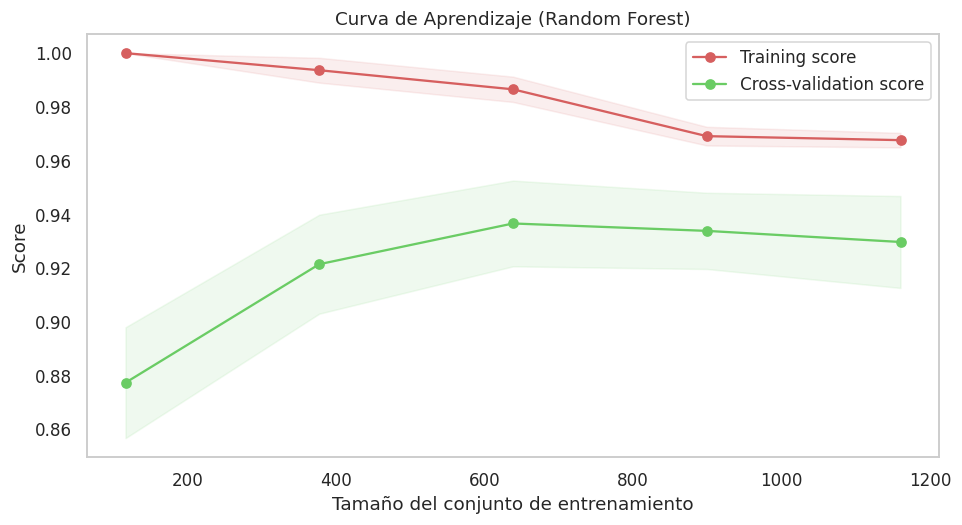

In [50]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, axes=None, ylim=None, cv=None,
                        n_jobs=None, train_sizes=np.linspace(.1, 1.0, 5)):
    if axes is None:
        _, axes = plt.subplots(1, 1, figsize=(10, 5))

    axes.set_title(title)
    if ylim is not None:
        axes.set_ylim(*ylim)
    axes.set_xlabel('Tamaño del conjunto de entrenamiento')
    axes.set_ylabel('Score')

    train_sizes, train_scores, test_scores, fit_times, _ = \
        learning_curve(estimator, X, y, cv=cv, n_jobs=n_jobs,
                       train_sizes=train_sizes, return_times=True)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    # Plot learning curve
    axes.grid()
    axes.fill_between(train_sizes, train_scores_mean - train_scores_std,
                         train_scores_mean + train_scores_std, alpha=0.1,
                         color='r')
    axes.plot(train_sizes, train_scores_mean, 'o-', color='r',
                 label='Training score')
    axes.fill_between(train_sizes, test_scores_mean - test_scores_std,
                         test_scores_mean + test_scores_std, alpha=0.1,
                         color='g')
    axes.plot(train_sizes, test_scores_mean, 'o-', color='g',
                 label='Cross-validation score')
    axes.legend(loc='best')
    return plt

# Configurar el Random Forest Classifier con los parámetros finales
rf_final = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42,
    class_weight='balanced'
)

# Plotear la curva de aprendizaje para Random Forest
plt.figure(figsize=(10, 5))
plot_learning_curve(rf_final, 'Curva de Aprendizaje (Random Forest)', X_train_pca, y_train, cv=5, n_jobs=-1)
plt.show()

CURVA PARA XG BOOST

<Figure size 1100x550 with 0 Axes>

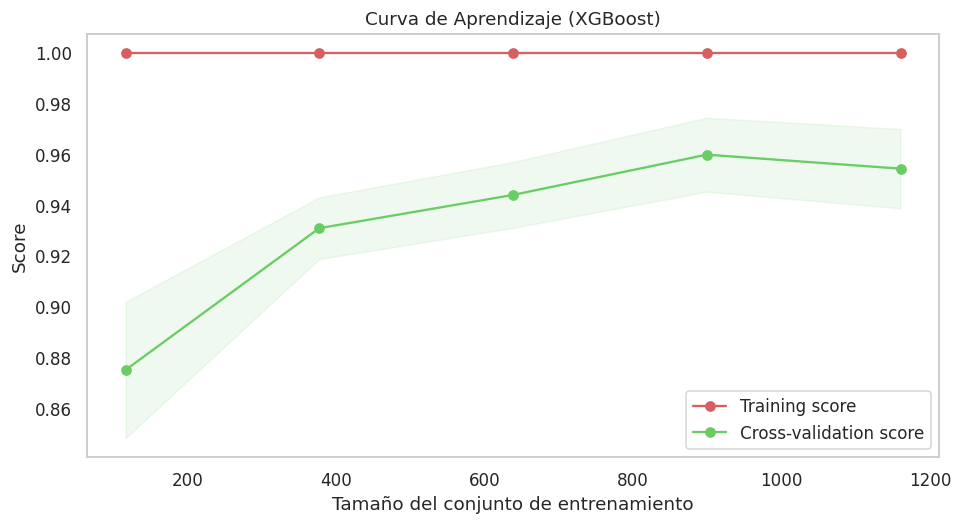

In [51]:
# Configurar el XGBoost Classifier con los parámetros finales (ajustar max_depth si se determinó uno mejor en el análisis de sensibilidad)
xgb_final = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=len(np.unique(y_train)),
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3, # Usamos 3 ya que el análisis de sensibilidad mostró un mejor gap
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

# Plotear la curva de aprendizaje para XGBoost
plt.figure(figsize=(10, 5))
plot_learning_curve(xgb_final, 'Curva de Aprendizaje (XGBoost)', X_train_pca, y_train, cv=5, n_jobs=-1)
plt.show()

## Sección 6 — Prueba del modelo con un paciente colombiano simulado

Aquí tomamos un paciente ficticio con valores clínicos típicos del contexto colombiano,  
lo pasamos por el **mismo pipeline** (imputación → escalado → PCA → Random Forest)  
y obtenemos las **probabilidades de pertenencia a cada cluster de riesgo**.

> Los clusters son:  
> - **0 · Cardio-renal** — disfunción renal + perfil lipídico alterado  
> - **1 · Cardiovascular Inflamatorio** — presión alta + glucosa elevada  
> - **2 · Bajo Riesgo** — valores dentro de rangos normales

In [52]:
# ── Paciente colombiano simulado ──────────────────────────────────────────────
# Ajusta los valores según el caso clínico real que quieras probar.
# Las columnas deben coincidir exactamente con X_train.columns

paciente_datos = {
    "acido_urico":              5.8,   # mg/dL
    "c_total":                  210,   # mg/dL
    "creatinina":               1.1,   # mg/dL
    "celulas_medias":           88.0,  # fL
    "glucosa":                  105,   # mg/dL
    "granulocitos":             62.0,  # %
    "hdl":                      42,    # mg/dL
    "hematocrito":              43.0,  # %
    "hemoglobina":              14.2,  # g/dL
    "ldl":                      138,   # mg/dL
    "leucocitos":               7.5,   # 10³/µL
    "linfocitos":               32.0,  # %
    "plaquetas":                250,   # 10³/µL
    "trigliceridos":            185,   # mg/dL
    "edad":                     52,    # años
    "sexo":                     1,     # 1=masculino
    "zona":                     1,     # 1=urbano
    "cigarrillo_cantidad_diaria": 5,
    "alcohol_anos_uso":         10,
    "ap_diabetes":              0,
    "ap_hipertension":          1,
    "af_diabetes":              0,
    "af_hipertension":          1,
    "ta_sistolica":             138,   # mmHg
    "ta_diastolica":            88,    # mmHg
    "peso":                     82,    # kg
    "talla":                    172,   # cm
    "imc":                      27.7,  # kg/m²
    "TFG":                      72,    # mL/min/1.73m²
}

# ── Construir DataFrame con las mismas columnas que X_train ───────────────────
paciente_df = pd.DataFrame([paciente_datos])

# Asegurarse de que solo estén las columnas que usó el modelo
columnas_modelo = X_train.columns.tolist()
for col in columnas_modelo:
    if col not in paciente_df.columns:
        paciente_df[col] = np.nan          # columna faltante → NaN (el imputer lo maneja)

paciente_df = paciente_df[columnas_modelo]  # mismo orden

print("Columnas del paciente:", paciente_df.shape)
print(paciente_df.T)


Columnas del paciente: (1, 22)
                     0
creatinina         1.1
celulas_medias    88.0
glucosa          105.0
granulocitos      62.0
hdl               42.0
hematocrito       43.0
hemoglobina       14.2
ldl              138.0
leucocitos         7.5
linfocitos        32.0
plaquetas        250.0
trigliceridos    185.0
edad              52.0
sexo               1.0
zona               1.0
ap_hipertension    1.0
ta_sistolica     138.0
ta_diastolica     88.0
peso              82.0
talla            172.0
imc               27.7
TFG               72.0


In [53]:
# ── Pipeline: Escalado → PCA → Predicción ────────────────────────────────────
CLUSTER_NOMBRES = {
    0: "Cardio-renal",
    1: "Cardiovascular Inflamatorio",
    2: "Bajo Riesgo"
}

CLUSTER_DESCRIPCION = {
    0: ("Perfil de disfunción renal con alteración lipídica. "
        "Se recomienda evaluación nefrológica y manejo agresivo del colesterol."),
    1: ("Perfil inflamatorio-cardiovascular: presión arterial elevada y glucosa "
        "en rango de prediabetes. Seguimiento cardiológico y control metabólico prioritarios."),
    2: ("Perfil de bajo riesgo cardiovascular. "
        "Se recomienda mantener hábitos saludables y revisión anual de rutina.")
}

# 1. Escalar con el scaler entrenado
paciente_scaled = scaler.transform(paciente_df.values)

# 2. Proyectar en el espacio PCA entrenado
paciente_pca = pca_final.transform(paciente_scaled)

# 3. Predicción puntual y probabilidades
cluster_pred   = rf.predict(paciente_pca)[0]
probabilities  = rf.predict_proba(paciente_pca)[0]

# ── Presentación clínica ──────────────────────────────────────────────────────
print("=" * 60)
print("       INFORME DE RIESGO CARDIOVASCULAR — ARTERY")
print("=" * 60)

for idx, prob in enumerate(probabilities):
    nombre = CLUSTER_NOMBRES[idx]
    barra  = "█" * int(prob * 30)
    print(f"  Cluster {idx} · {nombre:<30} {prob*100:5.1f}%  {barra}")

print()
print(f"  ► Clasificación principal : Cluster {cluster_pred} · {CLUSTER_NOMBRES[cluster_pred]}")
print(f"  ► Probabilidad asignada   : {probabilities[cluster_pred]*100:.1f}%")
print()
print("  Interpretación clínica:")
print(f"  {CLUSTER_DESCRIPCION[cluster_pred]}")
print("=" * 60)


       INFORME DE RIESGO CARDIOVASCULAR — ARTERY
  Cluster 0 · Cardio-renal                    88.1%  ██████████████████████████
  Cluster 1 · Cardiovascular Inflamatorio      6.9%  ██
  Cluster 2 · Bajo Riesgo                      5.0%  █

  ► Clasificación principal : Cluster 0 · Cardio-renal
  ► Probabilidad asignada   : 88.1%

  Interpretación clínica:
  Perfil de disfunción renal con alteración lipídica. Se recomienda evaluación nefrológica y manejo agresivo del colesterol.


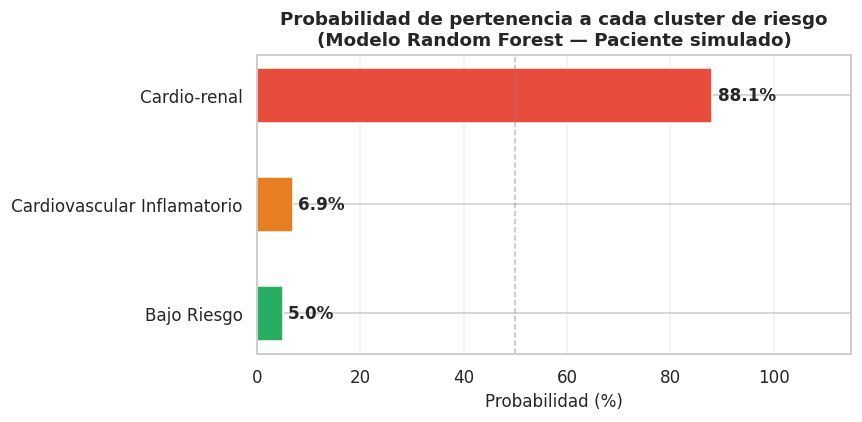

In [54]:
# ── Visualización de probabilidades ──────────────────────────────────────────
import matplotlib.patches as mpatches

cluster_nombres_lista = [CLUSTER_NOMBRES[i] for i in range(3)]
colores = ["#e74c3c", "#e67e22", "#27ae60"]   # rojo, naranja, verde

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(cluster_nombres_lista, probabilities * 100, color=colores, edgecolor="white", height=0.5)

for bar, prob in zip(bars, probabilities):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            f"{prob*100:.1f}%", va="center", fontweight="bold", fontsize=11)

ax.set_xlim(0, 115)
ax.set_xlabel("Probabilidad (%)", fontsize=11)
ax.set_title("Probabilidad de pertenencia a cada cluster de riesgo\n(Modelo Random Forest — Paciente simulado)",
             fontsize=12, fontweight="bold")
ax.axvline(x=50, color="gray", linestyle="--", alpha=0.5, linewidth=1)
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


## Sección 7 — Exportación de modelos a `.pkl`

Guardamos todos los artefactos necesarios para que el backend de **cardio-backend** los cargue en producción:

| Archivo | Uso en el backend |
|---|---|
| `random_forest.pkl` | Clasificador principal → `model_loader.py` |
| `xgboost_model.pkl` | Modelo alternativo → `model_loader.py` |
| `scaler.pkl` | Escalado de features crudas → `preprocessing.py` |
| `pca.pkl` | Proyección PCA → `preprocessing.py` |
| `kmeans.pkl` | Referencia de clusters → `prediction_service.py` |

> **Nota:** los `.pkl` en `cardio-backend/models/` ya estan cambiados de los viejos notebooks y se añadieron `scaler.pkl`, `pca.pkl`, `kmeans.pkl` pero falta actualizar `model_loader.py` y .env
> para cargar `scaler.pkl` y `pca.pkl` además de los modelos.

In [55]:
import pickle
import os

# ── Directorio de salida ──────────────────────────────────────────────────────
# En Colab los archivos quedan en /content/ y puedes descargarlos con
# files.download() o copiarlos a Google Drive.
OUTPUT_DIR = "/content/models_artery"
os.makedirs(OUTPUT_DIR, exist_ok=True)

artefactos = {
    "random_forest.pkl" : rf,
    "xgboost_model.pkl" : xgb_model,
    "scaler.pkl"        : scaler,
    "pca.pkl"           : pca_final,
    "kmeans.pkl"        : kmeans_final,
}

print("Guardando artefactos en", OUTPUT_DIR)
for nombre, obj in artefactos.items():
    ruta = os.path.join(OUTPUT_DIR, nombre)
    with open(ruta, "wb") as f:
        pickle.dump(obj, f)
    size_kb = os.path.getsize(ruta) / 1024
    print(f"  ✔  {nombre:<25}  ({size_kb:.1f} KB)")

print("\nTodos los artefactos exportados correctamente.")


Guardando artefactos en /content/models_artery
  ✔  random_forest.pkl          (699.1 KB)
  ✔  xgboost_model.pkl          (506.9 KB)
  ✔  scaler.pkl                 (1.3 KB)
  ✔  pca.pkl                    (3.4 KB)
  ✔  kmeans.pkl                 (6.5 KB)

Todos los artefactos exportados correctamente.


In [56]:
# ── Descarga directa desde Colab ──────────────────────────────────────────────
# Ejecuta esta celda para descargar los .pkl a tu computador.
# Si trabajas en local (Jupyter), omite esta celda.

from google.colab import files
import glob

for ruta in sorted(glob.glob(f"{OUTPUT_DIR}/*.pkl")):
    print(f"  Descargando {os.path.basename(ruta)} …")
    files.download(ruta)

print("\n✔ Descarga completada. Coloca los .pkl en cardio-backend/models/")


  Descargando kmeans.pkl …


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  Descargando pca.pkl …


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  Descargando xgboost_model.pkl …


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✔ Descarga completada. Coloca los .pkl en cardio-backend/models/


In [57]:
# ── Verificación de integridad: cargar y re-predecir ─────────────────────────
print("=== Verificación de carga y predicción ===\n")

cargados = {}
for nombre in artefactos.keys():
    ruta = os.path.join(OUTPUT_DIR, nombre)
    with open(ruta, "rb") as f:
        cargados[nombre] = pickle.load(f)
    print(f"  ✔ {nombre} cargado correctamente")

# Re-predecir con el paciente simulado usando los artefactos cargados
pac_scaled_v  = cargados["scaler.pkl"].transform(paciente_df.values)
pac_pca_v     = cargados["pca.pkl"].transform(pac_scaled_v)
pred_v        = cargados["random_forest.pkl"].predict(pac_pca_v)[0]
probs_v       = cargados["random_forest.pkl"].predict_proba(pac_pca_v)[0]

print(f"\n  Predicción verificada: Cluster {pred_v} · {CLUSTER_NOMBRES[pred_v]}")
print(f"  Probabilidades: { {CLUSTER_NOMBRES[i]: f'{p*100:.1f}%' for i, p in enumerate(probs_v)} }")
print("\n✔ Los artefactos son equivalentes a los entrenados en memoria.")


=== Verificación de carga y predicción ===

  ✔ random_forest.pkl cargado correctamente
  ✔ xgboost_model.pkl cargado correctamente
  ✔ scaler.pkl cargado correctamente
  ✔ pca.pkl cargado correctamente
  ✔ kmeans.pkl cargado correctamente

  Predicción verificada: Cluster 0 · Cardio-renal
  Probabilidades: {'Cardio-renal': '88.1%', 'Cardiovascular Inflamatorio': '6.9%', 'Bajo Riesgo': '5.0%'}

✔ Los artefactos son equivalentes a los entrenados en memoria.
